## Imports and setup

In [1]:
# Import required libraries
import os
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import networkx as nx
from scipy.stats import pearsonr
from functools import partial
from pathlib import Path
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device detection and setup
def get_device():
    """Detect and return the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Metal Performance Shaders) device")
    else:
        device = torch.device('cpu')
        print("Using CPU device")
    
    print(f"PyTorch version: {torch.__version__}")
    return device

# Set device
device = get_device()

Using MPS (Metal Performance Shaders) device
PyTorch version: 2.8.0


## New objective

Rather than trying having an _a priori_ assumption/hypothesis that the attentionmatrix should have some structure that we hope is the connectome, we should just show in a well established problem that the attention matrix learned is something useful. Then whatever it is that we learn from the neural data, even if it's not the connectome, it's still something that we can assert has some utility.

# ============================================================================
# Phase 1: TRANSCRIPTOMICS as Embeddings
# ============================================================================

In [ ]:
# Configuration
CONFIG_TRANSCRIPTOMICS = {
    'embedding_dim': 2048,  # D - configurable embedding dimension (for feature selection)
    'hidden_dim': 512,      # Hidden dimension for Q/K projections
    'batch_size': 32,       # Batch size for training
    'learning_rate': 1e-3,  # Learning rate
    'num_samples': 9600,     # Total number of samples (dataset repeats same data this many times)
    'use_attention_scores': False, # Use attention scores instead of weights
    'use_mlp_projections': False,  # Use MLP instead of Linear for Q/K projections
    'attn_dropout': 0.01,  # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,  # Weight for batch consistency regularization
    'consistency_type': 'variance',  # 'variance' (default) or 'frobenius'
    'n_layers': 1,           # Number of decoder blocks (1 = shallow, >1 = deep)
    'mlp_expansion': 2,      # MLP hidden layer expansion factor
    'dropout': 0.1,          # Dropout rate for MLP layers
}

print("Phase 1 Configuration (Transcriptomics):")
for key, value in CONFIG_TRANSCRIPTOMICS.items():
    print(f"  {key}: {value}")
print(f"\nDevice: {device}")

Phase 1 Configuration (Transcriptomics):
  embedding_dim: 2048
  hidden_dim: 512
  batch_size: 32
  learning_rate: 0.001
  num_samples: 9600
  use_attention_scores: False
  use_mlp_projections: False
  attn_dropout: 0.05
  consistency_weight: 0.0
  consistency_type: variance
  n_layers: 1
  mlp_expansion: 2
  dropout: 0.1

Device: mps


## Data Preparation and Embedding Generation

We start by loading the single-cell transcriptome data. This dataset contains gene expression data for 22,469 genes across 130 neuron classes, providing much more granular resolution than bulk-sorted data.

Our approach:
1. Load and preprocess the transcriptome data
2. Apply log1p transformation and standardization
3. Optionally, perform PCA to reduce dimensionality and visualization
4. Generate initial (N, D) embedding matrix where N=130 neuron classes


In [3]:
# Load GSE136049 neuron-class transcriptome (preferring log-normalized means)
transcriptomics_data_dir = 'data/transcriptomics/Single Cell Seq/GEO (GSE 136049)'
lognorms_path = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_lognorm_means.csv'
counts_path    = f'{transcriptomics_data_dir}/GSE136049_genes_by_neurons_counts.csv'
preferred_path = lognorms_path

if os.path.exists(preferred_path):
    df = pd.read_csv(preferred_path, index_col=0)
    used = preferred_path
    X_ = df.T.values  # neurons x genes
else:
    assert os.path.exists(counts_path), "Missing GSE136049 CSVs; run load_data.ipynb first."
    df = pd.read_csv(counts_path, index_col=0)
    used = counts_path
    # counts → log1p before standardization
    X_ = np.log1p(df.T.values)

# NOTE: We are using the term "labels" to just mean the name (i.e. string) that is assigned to the neuron. 
# In the transcritomic data those labels are a mixture of neuron class and class members.
neuron_labels_transcriptomics = df.columns.tolist()
transcript_names = df.index.tolist()
print(f"Loaded: {used}")
print(f"Original table shape (genes x neuron_labels): {df.shape}")
print(f"Transposed to (neurons x genes): {X_.shape}")
print(f"Neuron names (first 10): {neuron_labels_transcriptomics[:10]}")
print(f"Feature names (first 10): {transcript_names[:10]}")

X_original = X_
print(f"X_original shape: {X_original.shape}")
# NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance information.
print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

N_neurons = len(neuron_labels_transcriptomics)
assert N_neurons == X_original.shape[0]
print(f"Number of neurons: {N_neurons}")
print(f"Neuron names: {neuron_labels_transcriptomics}")


Loaded: data/transcriptomics/Single Cell Seq/GEO (GSE 136049)/GSE136049_genes_by_neurons_lognorm_means.csv
Original table shape (genes x neuron_labels): (22469, 130)
Transposed to (neurons x genes): (130, 22469)
Neuron names (first 10): ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY']
Feature names (first 10): ['WBGene00010957', 'WBGene00010958', 'WBGene00014454', 'WBGene00010959', 'WBGene00010960', 'WBGene00010961', 'WBGene00000829', 'WBGene00010962', 'WBGene00010963', 'WBGene00010964']
X_original shape: (130, 22469)
Without standardization (22469,) genes (first 5) 
	mean: [2.87590796 1.01728045 0.8490579  1.07566784 1.96477043], 
	std: [0.92014032 0.41039817 0.42220107 0.57693753 0.81696442]
Number of neurons: 130
Neuron names: ['ADA', 'ADE', 'ADF', 'ADL', 'AFD', 'AIA', 'AIB', 'AIM', 'AIN', 'AIY', 'AIZ', 'ALA', 'ALM', 'ALN', 'AQR', 'AS', 'ASEL', 'ASER', 'ASG', 'ASH', 'ASI', 'ASJ', 'ASK', 'AUA', 'AVA', 'AVB', 'AVD', 'AVE', 'AVF', 'AVG', 'AVH', 'AVJ', 'AVK', 'AVL'

#### By morphological criteria, the 302 neurons of the worm are classified into 118 distinct types, and from the database of reporter transgene expression patterns, most of these are postulated to have unique molecular signatures.

File used was obtained from the [supplemental information](https://www.sciencedirect.com/science/article/pii/S096098221631212X?via%3Dihub#app2) of this paper:
   >  Hobert, O., Glenwinkel, L. & White, J. Revisiting Neuronal Cell Type Classification in Caenorhabditis elegans. Curr. Biol. 26, R1197–R1203 (2016).


In [4]:
# Load neuron metadata from supplementary data file, including columns for neuron class, member, lineage, cell type, and neurotransmitter identity
neuron_metadata_df = pd.read_excel(
    'data/1-s2.0-S096098221631212X-mmc2.xlsx', 
    sheet_name='List_with_genes.txt',
    header=3,    # Headers are on row 4 (0-based index 3)
    nrows=302,   # Data is in rows 5-306 (302 rows total)
    usecols=[0,1,2,3,4]  # Columns: Neuron class, Class member, Lineage, Cell type, Neurotransmitter identity
).ffill() # Forward fill empty cells to handle merged-cell-like data

print(f"Loaded neuron metadata: {neuron_metadata_df.shape}")
print(f"Columns: {neuron_metadata_df.columns.tolist()}")
print(f"Sample rows:")
print(neuron_metadata_df.head())

# Build lookup dictionaries assuming a *unique* mapping of neuron class to cell type and to neurotransmitter
label_to_neurotransmitter = dict(zip(
    neuron_metadata_df['Class member'], 
    neuron_metadata_df['Neurotransmitter identity']
))
class_to_neurotransmitter = dict(zip(
    neuron_metadata_df['Neuron class'],
    neuron_metadata_df['Neurotransmitter identity']
))

# Create lookup dictionary mapping labels to their neuron class
label_to_class = dict(zip(
    neuron_metadata_df['Class member'],
    neuron_metadata_df['Neuron class']
))

# Lookup dictionaries for neuron type (Sensory, Motor, Inter, Pharyngeal)
label_to_type = dict(zip(
    neuron_metadata_df['Class member'],
    neuron_metadata_df['Cell type']
))
class_to_type = dict(zip(
    neuron_metadata_df['Neuron class'],
    neuron_metadata_df['Cell type']
))

print(f"\nLookup dictionaries created:")
print(f"  label_to_neurotransmitter: {len(label_to_neurotransmitter)} entries")
print(f"  class_to_neurotransmitter: {len(class_to_neurotransmitter)} entries")
print(f"  label_to_class: {len(label_to_class)} entries")
print(f"  label_to_type: {len(label_to_type)} entries")
print(f"  class_to_type: {len(class_to_type)} entries")


Loaded neuron metadata: (302, 5)
Columns: ['Neuron class', 'Class member', 'Lineage', 'Cell type', 'Neurotransmitter identity']
Sample rows:
  Neuron class Class member        Lineage Cell type Neurotransmitter identity
0          ADA         ADAL  AB.plapaaaapp     inter                       Glu
1          ADA         ADAR  AB.prapaaaapp     inter                       Glu
2          ADE         ADEL  AB.plapaaaapa   Sensory                        DA
3          ADE         ADER  AB.prapaaaapa   Sensory                        DA
4          ADF         ADFL   AB.alpppppaa   Sensory                       Ach

Lookup dictionaries created:
  label_to_neurotransmitter: 302 entries
  class_to_neurotransmitter: 118 entries
  label_to_class: 302 entries
  label_to_type: 302 entries
  class_to_type: 118 entries


In [5]:
# Map each neuron name in neuron_labels_transcriptomics to its neurotransmitter, class, and type
neuron_neurotransmitters = []
neuron_classes = []
neuron_types = []

for neuron in neuron_labels_transcriptomics:
    # Clean neuron name as before
    neuron_clean = neuron.split('_')[0].replace('0', '')  # This keeps VA10 issue for now

    # Initialize all as missing
    nt = '<Missing>'
    cls = '<Missing>'
    ntype = '<Missing>'

    # First try exact match in label dictionaries
    if neuron_clean in label_to_neurotransmitter:
        nt = label_to_neurotransmitter[neuron_clean]
    if neuron_clean in label_to_class:
        cls = label_to_class[neuron_clean]
    if neuron_clean in label_to_type:
        ntype = label_to_type[neuron_clean]

    # Try class-level lookup if needed
    if nt == '<Missing>' and neuron_clean in class_to_neurotransmitter:
        nt = class_to_neurotransmitter[neuron_clean]
    if cls == '<Missing>' and neuron_clean in class_to_neurotransmitter:
        cls = neuron_clean  # treat as a class name if only found there
    if ntype == '<Missing>' and neuron_clean in class_to_type:
        ntype = class_to_type[neuron_clean]

    neuron_neurotransmitters.append(nt)
    neuron_classes.append(cls)
    neuron_types.append(ntype)

# Convert to arrays
neuron_neurotransmitters = np.array(neuron_neurotransmitters)
neuron_classes = np.array(neuron_classes)
neuron_types = np.array(neuron_types)

print(f"\nNeuron metadata mapping:")
print(f"Total neurons: {len(neuron_labels_transcriptomics)}")
print(f"Unique neurotransmitters: {np.unique(neuron_neurotransmitters)}")
print(f"Unique classes: {np.unique(neuron_classes)}")
print(f"Unique types: {np.unique(neuron_types)}")
print(f"Unknown neurotransmitters: {(neuron_neurotransmitters == '<Missing>').sum()}")
print(f"Unknown classes: {(neuron_classes == '<Missing>').sum()}")
print(f"Unknown types: {(neuron_types == '<Missing>').sum()}")

# Show some examples of the mapping
print(f"\nSample mappings:")
for i in range(min(10, len(neuron_labels_transcriptomics))):
    print(f"  {neuron_labels_transcriptomics[i]} -> NT: {neuron_neurotransmitters[i]}, Class: {neuron_classes[i]}, Type: {neuron_types[i]}")



Neuron metadata mapping:
Total neurons: 130
Unique neurotransmitters: ['5HT' 'ACh' 'ACh (minor)' 'Ach' 'DA' 'GABA' 'Glu' 'Glu & 5HT'
 'Octopamine' 'Unknown (orphan)' 'unknown MA (cat-1)']
Unique classes: ['ADA' 'ADE' 'ADF' 'ADL' 'AFD' 'AIA' 'AIB' 'AIM' 'AIN' 'AIY' 'AIZ' 'ALA'
 'ALM' 'ALN' 'AQR' 'AS' 'ASE' 'ASG' 'ASH' 'ASI' 'ASJ' 'ASK' 'AUA' 'AVA'
 'AVB' 'AVD' 'AVE' 'AVF' 'AVG' 'AVH' 'AVJ' 'AVK' 'AVL' 'AVM' 'AWA' 'AWB'
 'AWC' 'BAG' 'BDU' 'CAN' 'CEP' 'DA' 'DB' 'DVA' 'DVB' 'DVC' 'FLP' 'HSN'
 'I1' 'I2' 'I3' 'I4' 'I5' 'I6' 'IL1' 'IL2' 'LUA' 'M1' 'M2' 'M3' 'M4' 'M5'
 'MC' 'MI' 'NSM' 'OLL' 'OLQ' 'PDA' 'PDB' 'PDE' 'PHA' 'PHB' 'PHC' 'PLM'
 'PLN' 'PQR' 'PVC' 'PVD' 'PVM' 'PVN' 'PVP' 'PVQ' 'PVR' 'PVT' 'PVW' 'RIA'
 'RIB' 'RIC' 'RID' 'RIF' 'RIG' 'RIH' 'RIM' 'RIP' 'RIR' 'RIS' 'RIV' 'RMD'
 'RME' 'RMF' 'RMG' 'RMH' 'SAA' 'SAB' 'SDQ' 'SIA' 'SIB' 'SMB' 'SMD' 'URA'
 'URB' 'URX' 'URY' 'VA' 'VB' 'VC' 'VD']
Unique types: ['Motor' 'Sensory' 'inter' 'pharyngeal']
Unknown neurotransmitters: 0
Unknown classes: 0

### Principal Component Analysis (PCA) on the original data

This allows us to visualize if th data always show distinctive groupings (e.g. by neurotransmitter or class) in low dimensions.

Applying PCA preprocessing to reduce dimensions and visualize data...
Original data shape: (130, 22469)
Using 129 PCA components (max allowable: 129)
PCA preprocessed data shape: (130, 129)
Explained variance ratio (first 10 components): [0.1010845  0.0711716  0.04499718 0.04002918 0.03708121 0.03003903
 0.02515988 0.02317245 0.02031772 0.01915597]
Total explained variance: 1.0000


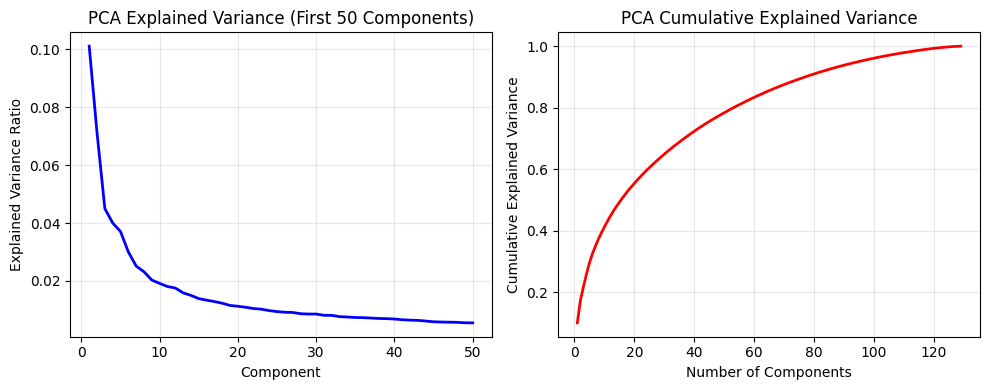

Plotting first two PCA components with metadata coloring...


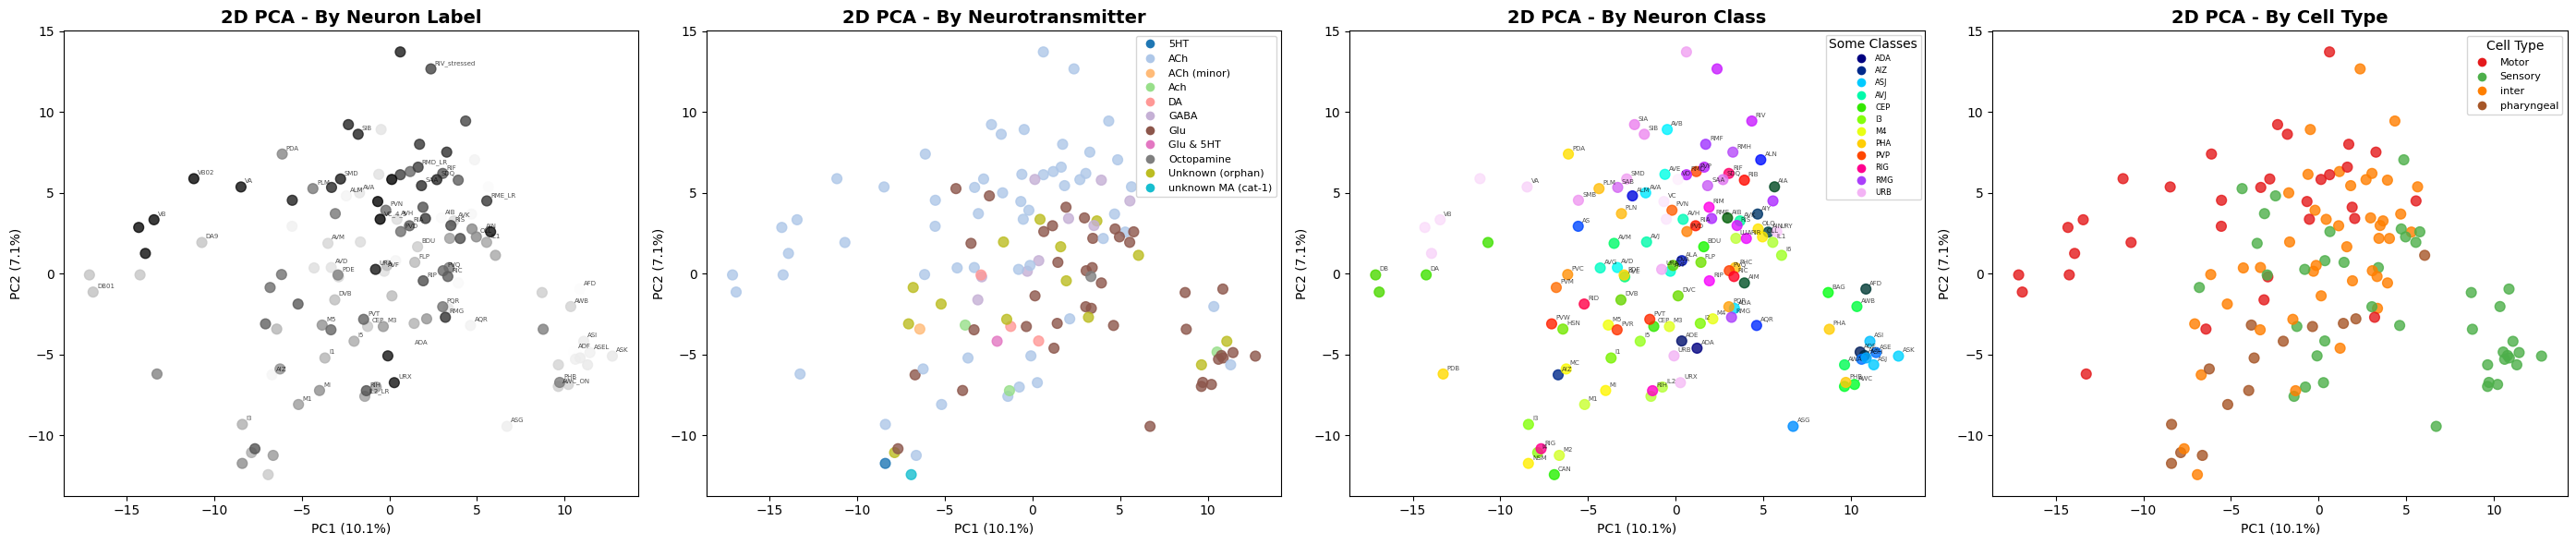

PCA visualization complete
X_pca shape: (130, 129)
Number of neurons: 130
Number of principal components: 129

Applying MDS to visualize data in 2D...
MDS transformed data shape: (130, 2)


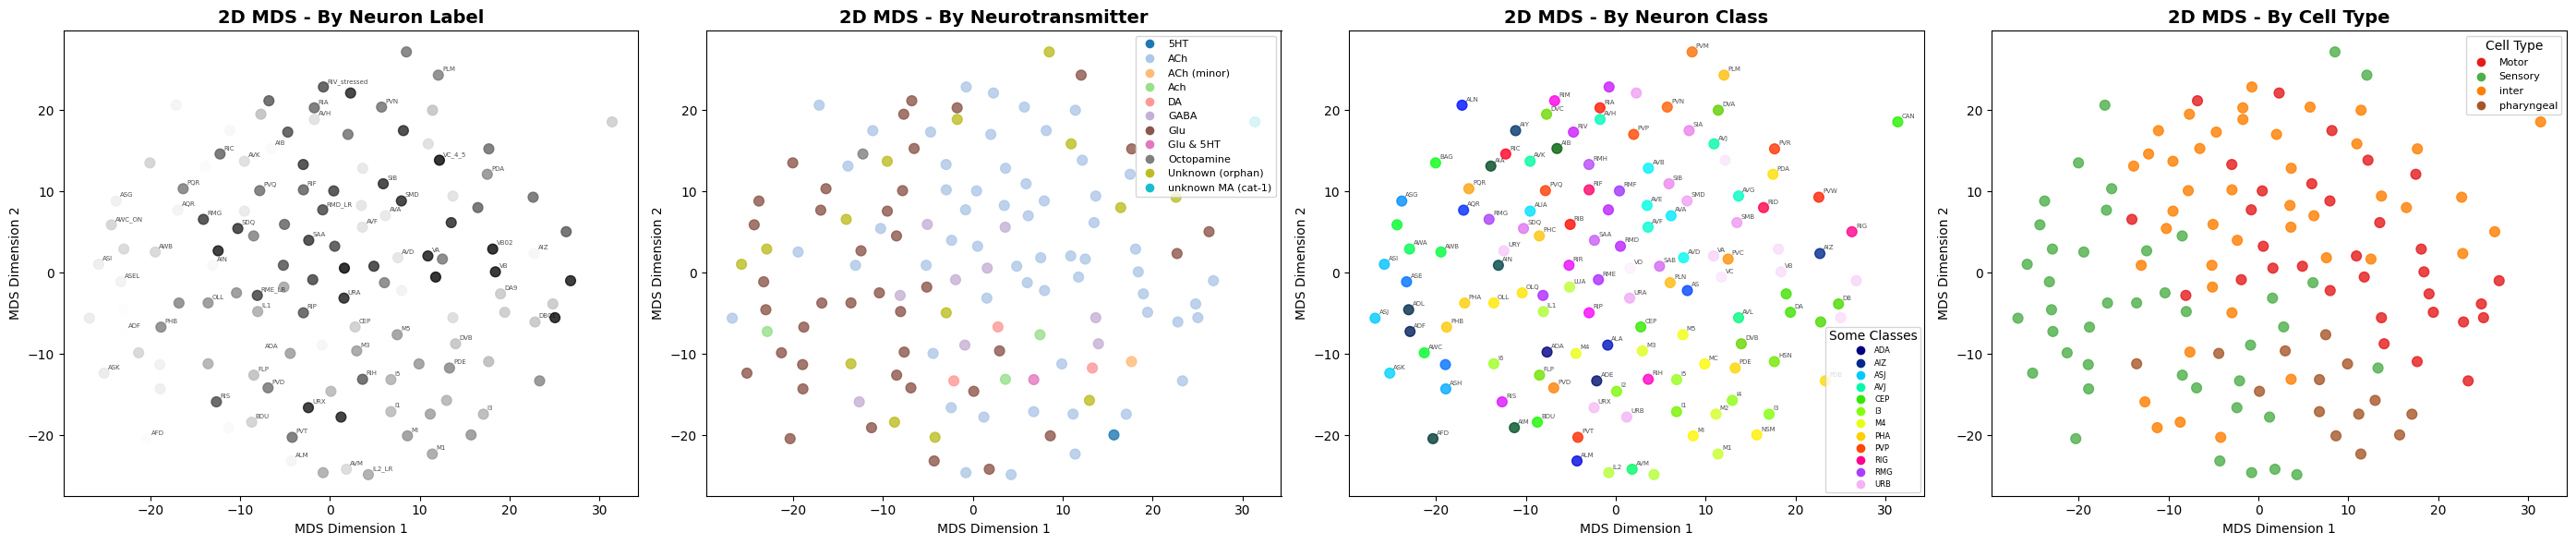

MDS visualization complete
X_mds shape: (130, 2)
Number of neurons: 130


In [6]:
# PCA Preprocessing for Dimensionality Reduction and Visualization
print("Applying PCA preprocessing to reduce dimensions and visualize data...")
print(f"Original data shape: {X_original.shape}")

# Maximum allowable PCA components is min(n_samples-1, n_features)
max_pca_components = min(N_neurons - 1, X_original.shape[1])
n_pca_components = max_pca_components  # Use maximum to preserve as much variance as possible

print(f"Using {n_pca_components} PCA components (max allowable: {max_pca_components})")

# Fit PCA
pca_preprocess = PCA(n_components=n_pca_components, random_state=41)
X_pca = pca_preprocess.fit_transform(X_original)

print(f"PCA preprocessed data shape: {X_pca.shape}")
print(f"Explained variance ratio (first 10 components): {pca_preprocess.explained_variance_ratio_[:10]}")
print(f"Total explained variance: {pca_preprocess.explained_variance_ratio_.sum():.4f}")

# Plot cumulative explained variance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, min(50, len(pca_preprocess.explained_variance_ratio_)) + 1), 
         pca_preprocess.explained_variance_ratio_[:50], 'b-', linewidth=2)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance (First 50 Components)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca_preprocess.explained_variance_ratio_) + 1), 
         np.cumsum(pca_preprocess.explained_variance_ratio_), 'r-', linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot first two PCA components for visualization with metadata coloring
print("Plotting first two PCA components with metadata coloring...")

# Create figure with 4 subplots: original coloring, neurotransmitter, neuron class, cell type
fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# Prepare metadata color mappings
unique_nt = np.sort(np.unique(neuron_neurotransmitters))
nt_to_color = {nt: i/len(unique_nt) for i, nt in enumerate(unique_nt)}
unique_cls = np.sort(np.unique(neuron_classes))
cls_to_color = {cls: i/len(unique_cls) for i, cls in enumerate(unique_cls)}
unique_types = np.sort(np.unique(neuron_types))
type_to_color = {ntype: i/len(unique_types) for i, ntype in enumerate(unique_types)}

# Use grayscale colormap for neuron labels and suitable colormaps for other categorical variables
label_cmap = plt.cm.Greys
nt_cmap = plt.cm.tab20  # Keep tab20 for neurotransmitters since there are few unique values
cls_cmap = plt.cm.gist_ncar  # Can handle many distinct values
type_cmap = plt.cm.Set1  # Set1 or similar for cell types (expecting few unique values)

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=range(len(neuron_labels_transcriptomics)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels_transcriptomics), 2):
    ax.annotate(neuron_labels_transcriptomics[i],
                (X_pca[i, 0], X_pca[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=nt_cmap(nt_to_color[nt]), 
                     markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D PCA - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for subset of classes (every kth class)
k = len(unique_cls) // 12 + 1  # Show ~12 classes
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cls_cmap(cls_to_color[cls]),
                     markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        idx = cls_indices[0]
        ax.annotate(cls, 
                   (X_pca[idx, 0], X_pca[idx, 1]),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=5, alpha=0.7)

# Plot 4: Colored by cell type
ax = axes[3]
colors = [type_cmap(type_to_color[ntype]) for ntype in neuron_types]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D PCA - By Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_preprocess.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_preprocess.explained_variance_ratio_[1]:.1%})')

# Add legend for cell types
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=type_cmap(type_to_color[ntype]), 
                     markersize=8, label=ntype) for ntype in unique_types]
ax.legend(handles=handles, loc='best', fontsize=8, title='Cell Type')

plt.tight_layout()
plt.show()

print("PCA visualization complete")
print(f"X_pca shape: {X_pca.shape}")
print(f"Number of neurons: {N_neurons}")
print(f"Number of principal components: {X_pca.shape[1]}")

# -----------------------------------------------------------
# MDS Visualization for Dimensionality Reduction (similar to above)
print("\nApplying MDS to visualize data in 2D...")

mds = MDS(n_components=2, dissimilarity='euclidean', random_state=41)
X_mds = mds.fit_transform(X_original)
print(f"MDS transformed data shape: {X_mds.shape}")

# Create figure with 4 subplots: original coloring, neurotransmitter, neuron class, cell type
fig, axes = plt.subplots(1, 4, figsize=(28, 6))

# Plot 1: Original (by neuron index) with annotations for every other neuron
ax = axes[0]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], 
                    c=range(len(neuron_labels_transcriptomics)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add text annotations for every other neuron
for i in range(0, len(neuron_labels_transcriptomics), 2):
    ax.annotate(neuron_labels_transcriptomics[i],
                (X_mds[i, 0], X_mds[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: Colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add legend for neurotransmitters
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=nt_cmap(nt_to_color[nt]), 
                      markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: Colored by neuron class with text annotations
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D MDS - By Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add legend for subset of classes (every kth class)
k = len(unique_cls) // 12 + 1  # Show ~12 classes
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                     markerfacecolor=cls_cmap(cls_to_color[cls]),
                     markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

# For each unique class, find one representative point and add text annotation
for cls in unique_cls:
    # Find indices where this class appears
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        idx = cls_indices[0]
        ax.annotate(cls, 
                   (X_mds[idx, 0], X_mds[idx, 1]),
                   xytext=(3, 3), textcoords='offset points',
                   fontsize=5, alpha=0.7)

# Plot 4: Colored by cell type
ax = axes[3]
colors = [type_cmap(type_to_color[ntype]) for ntype in neuron_types]
scatter = ax.scatter(X_mds[:, 0], X_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('2D MDS - By Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')

# Add legend for cell types
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=type_cmap(type_to_color[ntype]), 
                      markersize=8, label=ntype) for ntype in unique_types]
ax.legend(handles=handles, loc='best', fontsize=8, title='Cell Type')

plt.tight_layout()
plt.show()

print("MDS visualization complete")
print(f"X_mds shape: {X_mds.shape}")
print(f"Number of neurons: {N_neurons}")



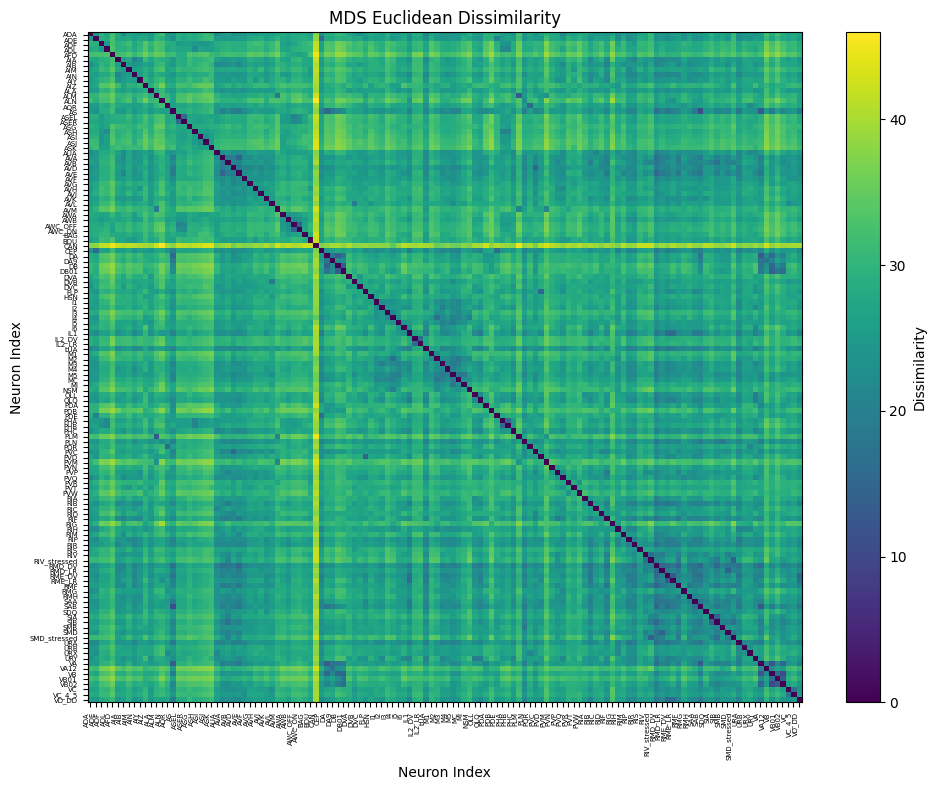

In [7]:
# Access the dissimilarity matrix
dissimilarity_matrix = mds.dissimilarity_matrix_

plt.figure(figsize=(10, 8))
plt.imshow(dissimilarity_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Dissimilarity')
plt.xlabel('Neuron Index')
plt.ylabel('Neuron Index')
plt.xticks(range(N_neurons), neuron_labels_transcriptomics, rotation=90, ha='right', fontsize=5)
plt.yticks(range(N_neurons), neuron_labels_transcriptomics, fontsize=5)
plt.title('MDS Euclidean Dissimilarity')
plt.tight_layout()

#### **OPTIONAL:** Choose either (a) a random subset of `input_dim` features to keep as the data in `X_original`, or (b) use the PCA-reduced data `X_pca` as `X_original`, to be embedded by the dataset class. Set `use_pca = True` to use PCA features, or `use_pca = False` to use a random subset of features.


In [8]:
# Option to either randomly choose a subset of features or use PCA-reduced data as X_original

use_pca = False  # <-- Set to True to use PCA reduced data (assumes X_pca exists), or False to use random subset of features

if use_pca:
    # Use precomputed PCA-reduced data
    X_original = X_pca  # Assumes X_pca has already been computed elsewhere
    print(f"Using PCA-reduced data as X_original. Shape: {X_original.shape}")
    print(f"First 5 features (mean): {X_original.mean(axis=0)[:5]}")
    print(f"First 5 features (std): {X_original.std(axis=0)[:5]}")

    # Update the embedding dimension in the config
    CONFIG_TRANSCRIPTOMICS['embedding_dim'] = X_original.shape[1]
else:
    # Randomly select a subset of features for X_original 
    input_dim = CONFIG_TRANSCRIPTOMICS['embedding_dim'] #X_original.shape[1]  # This can be set to desired fixed dimensionality
    print(f"X_original shape: {X_original.shape}")
    print(f"Selecting {input_dim} random features from {X_original.shape[1]} total features")

    # Randomly select input_dim features without replacement
    selected_features = np.random.choice(X_original.shape[1], size=input_dim, replace=False)
    print(f"Selected features: [{', '.join(map(str, selected_features[:5]))} ... {selected_features[-1]}]")

    # Create new X_original with only selected features
    X_original = X_original[:, selected_features]
    print(f"\nNew X_original shape: {X_original.shape}")
    # NOTE: Do NOT standardize features (genes) with StandardScaler. It strips away the variance information.
    print(f"Without standardization {X_original.mean(axis=0).shape} genes (first 5) \n\tmean: {X_original.mean(axis=0)[:5]}, \n\tstd: {X_original.std(axis=0)[:5]}")

    print(f"\nData ready for embedding: {X_original.shape}")

X_original shape: (130, 22469)
Selecting 2048 random features from 22469 total features
Selected features: [4704, 15071, 14981, 5564, 447 ... 13461]

New X_original shape: (130, 2048)
Without standardization (2048,) genes (first 5) 
	mean: [0.11445684 0.00069365 0.00016286 0.01129373 0.00013161], 
	std: [0.06226655 0.00428849 0.00184978 0.01740574 0.00105634]

Data ready for embedding: (130, 2048)


## Custom Transcriptome Dataset

Simple dataset that returns the same transcriptome data repeatedly for each sample. This allows us to train the model on the same data multiple times, with the dataset size determined by `num_samples`.

In [9]:
class TranscriptomeDataset(Dataset):
    """
    Simple dataset that returns the same transcriptome data for each sample.
    Used for training attention models on fixed transcriptomic embeddings.
    """
    def __init__(self, X_original, num_samples):
        """
        Args:
            X_original: (N_neurons, D) numpy array or torch tensor of transcriptome data
            num_samples: number of times to repeat the data (dataset length)
        """
        self.X_original = torch.tensor(X_original, dtype=torch.float32) if isinstance(X_original, np.ndarray) else X_original
        self.num_samples = num_samples
        self.N_neurons, self.D = self.X_original.shape
        print(f"TranscriptomeDataset: {self.N_neurons} neurons, {self.D} features, {self.num_samples} samples")
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        # Always return the same data (clone to avoid in-place modifications)
        return self.X_original.clone()


In [10]:
# Create transcriptomics dataset
print("Creating TranscriptomeDataset...")
transcriptome_dataset = TranscriptomeDataset(
    X_original=X_original,
    num_samples=CONFIG_TRANSCRIPTOMICS['num_samples']
)

# Test the dataset
print(f"Dataset length: {len(transcriptome_dataset)}")
print(f"Sample shape: {transcriptome_dataset[0].shape}")
print(f"Sample dtype: {transcriptome_dataset[0].dtype}")

# Verify all samples are identical
sample_0 = transcriptome_dataset[0]
sample_1 = transcriptome_dataset[1]
sample_last = transcriptome_dataset[-1]
print(f"\nAll samples identical: {torch.equal(sample_0, sample_1) and torch.equal(sample_0, sample_last)}")


Creating TranscriptomeDataset...
TranscriptomeDataset: 130 neurons, 2048 features, 9600 samples
Dataset length: 9600
Sample shape: torch.Size([130, 2048])
Sample dtype: torch.float32

All samples identical: True


## Attention Model Architecture with Random Dropout Masking

We implement the `SingleHeadSelfAttention` module that learns to reconstruct each neuron's embedding using only the embeddings of other neurons. The key innovations are:
1. Diagonal masking that prevents self-attention
2. Random dropout masking during training that forces robust attention patterns

**Architecture**:
- Input: (batch, N, D) tensor of neuron embeddings
- Output: reconstructed embeddings and attention weights
- Diagonal mask: A[i,i] = 0 (prevent self-attention)
- Random dropout mask: During training, randomly mask 1 additional neuron per row to prevent overfitting


In [11]:
class FeedForwardMLP(nn.Module):
    def __init__(self, input_dim, output_dim, mlp_expansion=2, dropout=0.1):
        """
        Two-layer feed-forward MLP with GELU activation and dropout.

        Args:
            input_dim: input feature dimension
            output_dim: output feature dimension
            mlp_expansion: expansion factor for hidden layer (default 4x)
            dropout: dropout rate
        """
        super().__init__()
        hidden_dim = int(input_dim * mlp_expansion)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)
        
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_hidden, use_attention_scores=False, use_mlp_projections=False, verbose_timing=False):
        """
        A single head of self-attention that projects input tokens to queries, keys and values.
        The value projection implements an identity function (i.e. the values `V` will equal the input `x`) 
        so no output projection needed.
        
        Args:
            d_model: the dimension of the input tokens (D)
            n_hidden: the hidden dimension for Q/K projections
            use_attention_scores: if True, use raw attention scores instead of softmax weights
            use_mlp_projections: if True, use FeedForwardMLP for Q/K projections instead of Linear
            verbose_timing: if True, print timing information for each step
        """
        super().__init__()
        # Q, K, and V projections
        # TODO: What if our Key and Query Projections were non-linear i.e. an MLP instead of a linear layer?
        if use_mlp_projections:
            self.W_Q = FeedForwardMLP(d_model, n_hidden, mlp_expansion=1, dropout=0.0)
            self.W_K = FeedForwardMLP(d_model, n_hidden, mlp_expansion=1, dropout=0.0)
        else:
            self.W_Q = nn.Linear(d_model, n_hidden, bias=False)  # Query projection
            self.W_K = nn.Linear(d_model, n_hidden, bias=False)  # Key projection
        self.W_V = nn.Identity()  # Value projection; Using Identity means values = inputs
        # NOTE: If we were to use multiple heads: 
        # W_Q and W_K would be torch.nn.Linear(d_model, n_hidden*num_heads, bias=False)
        # W_V would be num_heads Identity matrices vertically stacked 
        #     i.e. matrix shape (output_dim, input_dim) = (num_heads*d_model, d_model)
        #     id = torch.eye(d_model); param = torch.nn.Parameter( torch.concat( num_heads * (id, ) ), requires_grad=False )
        #     W_V = torch.nn.Linear(d_model, num_heads*d_model, bias=False); W_V.weight = param; 
        #     Just to make sure: [ param.requires_grad_(False) for param in W_V.parameters() ]
        self.d_model = d_model
        self.n_hidden = n_hidden
        self.use_attention_scores = use_attention_scores
        self.use_mlp_projections = use_mlp_projections
        self.verbose_timing = verbose_timing

    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        NOTE: Tokens in are the same shape as the tokens out (batch, n_neurons, d_model).
        Args:
            x: input token tensor (i.e. embeddings) of shape (batch, n_neurons, d_model)
            attn_mask: optional mask tensor of shape (batch, n_neurons, n_neurons); defaults to diagonal 'self' mask.
            attn_dropout: float between 0 and 1, fraction of neurons to randomly mask per row

        Returns:
            dict containing:
                - output: reconstructed embeddings of shape (batch, n_neurons, d_model)
                - attn_weights: attention weights of shape (batch, n_neurons, n_neurons)
                - attn_scores: attention scores of shape (batch, n_neurons, n_neurons)
                - attn_mask: attention mask of shape (batch, n_neurons, n_neurons)
        """
        start_time = time.time()
        batch_size, n_neurons, d_model = x.shape
        device = x.device

        # Compute Q, K, V projections
        Q = self.W_Q(x)  # (batch, n_neurons, n_hidden)
        K = self.W_K(x)  # (batch, n_neurons, n_hidden)
        V = self.W_V(x)  # (batch, n_neurons, d_model)
        # # NOTE: If we were to use multiple heads:
        # Q = self.W_Q(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # K = self.W_K(x).view((batch, n_neurons, -1, self.n_hidden)).transpose(1, 2) # (batch, num_heads, n_neurons, n_hidden)
        # V = self.W_V(x).view((batch, n_neurons, -1, self.d_model)).transpose(1, 2) # (batch, num_heads, n_neurons, d_model)
        print(f"QK/V projections done in {time.time() - start_time:.3f}s") if self.verbose_timing else None

        # Create base diagonal mask (1 everywhere except diagonal)
        mask_time = time.time()
        if attn_mask is None:
            attn_mask = (1 - torch.eye(n_neurons, device=device)).unsqueeze(0).expand(batch_size, -1, -1)
        
        # Apply attention dropout if specified
        if attn_dropout > 0:
            # Calculate number of neurons to mask per row
            n_mask = int(attn_dropout * n_neurons)
            if n_mask > 0:
                # Clone mask to avoid modifying the original
                attn_mask = attn_mask.clone()
                
                # Generate random permutations for all batch x neurons at once
                # Shape: (batch_size, n_neurons, n_neurons)
                random_perms = torch.stack([torch.randperm(n_neurons, device=device) 
                                         for _ in range(batch_size * n_neurons)]).view(batch_size, n_neurons, n_neurons)
                
                # Create mask from first n_mask indices of each permutation
                dropout_mask = torch.zeros((batch_size, n_neurons, n_neurons), device=device)
                dropout_mask.scatter_(2, random_perms[:, :, :n_mask], 1)
                
                # Apply dropout mask to attention mask
                attn_mask = attn_mask * (1 - dropout_mask)
        
        print(f"Attention masking done in {time.time() - mask_time:.3f}s") if self.verbose_timing else None

        # Compute attention
        attn_time = time.time()
        # Compute scaled dot-product attention scores
        scores = torch.bmm(Q, K.transpose(1, 2)) / (self.n_hidden**0.5)
        
        # Apply mask by setting masked positions to -inf
        inf_masked_scores = scores.masked_fill(attn_mask == 0, float("-inf"))

        # Compute masked attention weights
        attn_weights = torch.softmax(inf_masked_scores, dim=-1)

        # We want masked scores but with 0s instead of -infs for visualization
        attn_scores = scores.masked_fill(attn_mask == 0, 0.0)
        print(f"Attention computation done in {time.time() - attn_time:.3f}s") if self.verbose_timing else None

        # Apply attention to values
        recon_time = time.time()
        if self.use_attention_scores:
            reconstructed = torch.bmm(attn_scores, V)
        else:
            reconstructed = torch.bmm(attn_weights, V)
        print(f"Reconstruction done in {time.time() - recon_time:.3f}s") if self.verbose_timing else None
        print(f"Total forward pass time: {time.time() - start_time:.3f}s") if self.verbose_timing else None

        return {
            'output': reconstructed,
            'attn_weights': attn_weights,
            'attn_scores': attn_scores,
            'attn_mask': attn_mask
        }

### New idea

What if the connectome is a _cross_-attention between cell-type embeddings and neural dynamics embeddings? We know that neurons are organized into cell-types, and that cell-types are organized into neural circuits. What if we use the cell-type embeddings to attend to the neural dynamics embeddings? Think of using the transcriptome embeddings as queries and the neural dynamics as keys and values.

In [12]:
# Test the attention model
print("Testing SingleHeadSelfAttention model...")
print(f"Using device: {device}")

# Create model for transcriptomics
model_transcriptomics = SingleHeadSelfAttention(
    d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
    n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    use_mlp_projections=CONFIG_TRANSCRIPTOMICS['use_mlp_projections']
).to(device)

print(f"\nSingleHeadSelfAttention created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")
print(f"Model architecture: {model_transcriptomics}")


Testing SingleHeadSelfAttention model...
Using device: mps

SingleHeadSelfAttention created with 2,097,152 parameters
Model architecture: SingleHeadSelfAttention(
  (W_Q): Linear(in_features=2048, out_features=512, bias=False)
  (W_K): Linear(in_features=2048, out_features=512, bias=False)
  (W_V): Identity()
)


TranscriptomeDataset: 130 neurons, 2048 features, 32 samples
Test batch shape: torch.Size([32, 130, 2048])
Expected d_model: 2048
Actual data dimension: 2048

Masking without Dropout
	Time taken: 1.051s
	Attention shape: torch.Size([32, 130, 130])
	Reconstructed shape: torch.Size([32, 130, 2048])
	Reconstruction error: 6.221


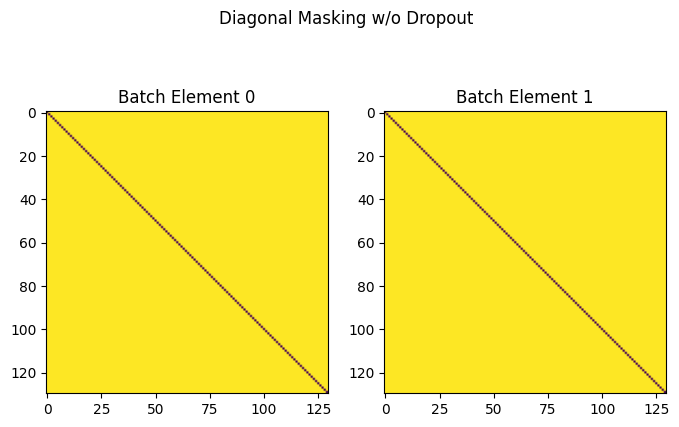


Masking with Dropout
	Time taken: 0.859s
	Attention shape: torch.Size([32, 130, 130])
	Reconstructed shape: torch.Size([32, 130, 2048])
	Reconstruction error: 6.222


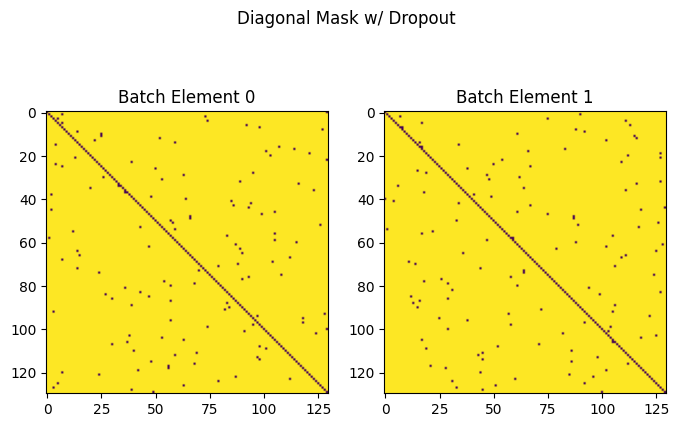

In [13]:
# Create a test batch from the transcriptome dataset
test_dataset = TranscriptomeDataset(
    X_original=X_original,
    num_samples=CONFIG_TRANSCRIPTOMICS['batch_size']
)
test_dataloader = DataLoader(test_dataset, batch_size=CONFIG_TRANSCRIPTOMICS['batch_size'], shuffle=False)
test_batch = next(iter(test_dataloader)).to(device)

print(f"Test batch shape: {test_batch.shape}")
print(f"Expected d_model: {CONFIG_TRANSCRIPTOMICS['embedding_dim']}")
print(f"Actual data dimension: {test_batch.shape[-1]}")

# Test with just the diagonal mask
model_transcriptomics.eval()
with torch.no_grad():
    start_time = time.time()
    output_regular = model_transcriptomics(test_batch, attn_dropout=0.0)
    reconstruction_error_regular = torch.norm(test_batch - output_regular['output'], dim=-1).mean()

print(f"\nMasking without Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_regular['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_regular['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_regular:.3f}")

# Plot the attention mask of two batch elements to show that the diagonal masking and that it is the same for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_regular['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_regular['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Masking w/o Dropout')
plt.show()

# Test with additional dropout masking
model_transcriptomics.train()
with torch.no_grad():
    start_time = time.time()
    output_dropout = model_transcriptomics(test_batch, attn_dropout=0.01)
    reconstruction_error_dropout = torch.norm(test_batch - output_dropout['output'], dim=-1).mean()

print(f"\nMasking with Dropout")
print(f"\tTime taken: {time.time() - start_time:.3f}s")
print(f"\tAttention shape: {output_dropout['attn_weights'].shape}")
print(f"\tReconstructed shape: {output_dropout['output'].shape}")
print(f"\tReconstruction error: {reconstruction_error_dropout:.3f}")

# Plot the attention mask of two batch elements to show that the dropout and that it is different for each element
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(output_dropout['attn_mask'][0].cpu())
axes[0].set_title('Batch Element 0')
axes[1].imshow(output_dropout['attn_mask'][1].cpu())
axes[1].set_title('Batch Element 1')
plt.suptitle('Diagonal Mask w/ Dropout')
plt.show()


## Deep Transformer Decoder Architecture

#### Overview
We implement a deep Transformer decoder architecture with stacked decoder blocks, each containing masked self-attention, feed-forward MLP, and layer normalization with residual connections using the **pre-norm** style.

### Decoder Block Architecture (Pre-Norm Style)
Each decoder block follows this architecture:
1. **LayerNorm → Masked Self-Attention → Residual**
2. **LayerNorm → MLP (Feed-Forward) → Residual**

#### Why Pre-Norm?
- **Training Stability**: Pre-norm architectures are more stable during training
- **Better Gradient Flow**: Layer normalization before each sub-layer improves gradient flow
- **Modern Standard**: Most recent Transformer implementations use pre-norm

#### Components
- **Masked Self-Attention**: Uses our `SingleHeadSelfAttention` with diagonal masking
- **MLP**: 2-layer feed-forward network with GELU activation and expansion factor (default 4x)
- **Layer Normalization**: Applied before each sub-layer (pre-norm style)
- **Residual Connections**: Skip connections around each sub-layer

#### Usage
- **Shallow Model** (`n_layers=1`): Equivalent to `SingleHeadSelfAttention` + MLP
- **Deep Model** (`n_layers>1`): Stacked decoder blocks for more complex representations

#### Transformer Decoder
![Decoder Architecture](figures/transformer_decoder.png)



In [14]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_hidden, mlp_expansion=4, dropout=0.1, 
                 use_attention_scores=False, use_mlp_projections=False,  
                 verbose_timing=False):
        """
        A single Transformer decoder block with pre-norm architecture.
        
        Architecture:
        1. LayerNorm → Masked Self-Attention → Residual
        2. LayerNorm → MLP (Feed-Forward) → Residual
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            mlp_expansion: expansion factor for MLP hidden layer (default 4x)
            dropout: dropout rate for MLP
            use_attention_scores: if True, use raw scores instead of softmax weights
            use_mlp_projections: if True, use MLP for Q/K projections instead of Linear
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        # Layer normalization
        self.input_layernorm = nn.LayerNorm(d_model)
        self.post_attention_layernorm = nn.LayerNorm(d_model)
        
        # Masked self-attention
        self.self_attn = SingleHeadSelfAttention(
            d_model=d_model,
            n_hidden=n_hidden,
            use_attention_scores=use_attention_scores,
            use_mlp_projections=use_mlp_projections,
            verbose_timing=verbose_timing
        )
        
        # Feed-forward MLP (now modularized and flexible)
        self.mlp = FeedForwardMLP(
            input_dim=d_model,
            output_dim=d_model,
            mlp_expansion=mlp_expansion,
            dropout=dropout
        )
        
        self.dropout = dropout
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0):
        """
        Forward pass with a pre-norm architecture.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking
        
        Returns:
            dict with keys:
                - 'output': output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights (batch, n_neurons, n_neurons)
                - 'attn_scores': attention scores (batch, n_neurons, n_neurons)
                - 'attn_mask': attention mask (batch, n_neurons, n_neurons)
        """
        # LayerNorm → Attention → Residual
        residual = x
        x_norm = self.input_layernorm(x) # Pre-attention layer norm
        attn_output = self.self_attn(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
        x = residual + attn_output['output']
        
        # LayerNorm → MLP → Residual
        residual = x
        x_norm = self.post_attention_layernorm(x) # Post-attention / Pre-MLP layer norm
        mlp_output = self.mlp(x_norm)
        x = residual + mlp_output
        
        return {
            'output': x,
            'attn_weights': attn_output['attn_weights'],
            'attn_scores': attn_output['attn_scores'],
            'attn_mask': attn_output['attn_mask']
        }


In [15]:
# Test DecoderBlock
print("\n1. Testing DecoderBlock...")
decoder_block = DecoderBlock(
    d_model=512,
    n_hidden=256,
    mlp_expansion=3,
    dropout=0.1,
    use_attention_scores=False,
    verbose_timing=False
).to(device)

# Test with sample input
test_input = torch.randn(4, 130, 512).to(device)  # batch=4, n_neurons=130, d_model=512
print(f"Input shape: {test_input.shape}")

# Forward pass
decoder_output = decoder_block(test_input, attn_dropout=0.01)
print(f"DecoderBlock output shape: {decoder_output['output'].shape}")
print(f"DecoderBlock attention weights shape: {decoder_output['attn_weights'].shape}")
print(f"DecoderBlock parameters: {sum(p.numel() for p in decoder_block.parameters()):,}")



1. Testing DecoderBlock...
Input shape: torch.Size([4, 130, 512])
DecoderBlock output shape: torch.Size([4, 130, 512])
DecoderBlock attention weights shape: torch.Size([4, 130, 130])
DecoderBlock parameters: 1,839,104


In [16]:
class DeepConnectomeTransformer(nn.Module):
    def __init__(self, d_model, n_hidden, n_layers=1, mlp_expansion=2, 
                 dropout=0.1, use_attention_scores=False, use_mlp_projections=False, 
                 verbose_timing=False):
        """
        Deep Transformer with stacked decoder blocks for connectome learning.
        
        Args:
            d_model: dimension of input/output embeddings
            n_hidden: hidden dimension for Q/K projections in attention
            n_layers: number of decoder blocks to stack
            mlp_expansion: expansion factor for MLP hidden layers
            dropout: dropout rate for MLP layers
            use_attention_scores: if True, use raw scores instead of softmax weights
            verbose_timing: if True, print timing information
        """
        super().__init__()
        
        self.n_layers = n_layers
        self.d_model = d_model
        
        # Stack of decoder blocks
        self.layers = nn.ModuleList([
            DecoderBlock(
                d_model=d_model,
                n_hidden=n_hidden,
                mlp_expansion=mlp_expansion,
                dropout=dropout,
                use_attention_scores=use_attention_scores,
                verbose_timing=verbose_timing
            )
            for _ in range(n_layers)
        ])
    
    def forward(self, x, attn_mask=None, attn_dropout=0.0, return_all_layers=False):
        """
        Forward pass through all decoder blocks.
        
        Args:
            x: input tensor (batch, n_neurons, d_model)
            attn_mask: optional attention mask (batch, n_neurons, n_neurons)
            attn_dropout: dropout rate for attention masking (applied at each layer)
            return_all_layers: if True, return attention info from all layers
        
        Returns:
            dict with keys:
                - 'output': final output tensor (batch, n_neurons, d_model)
                - 'attn_weights': attention weights from last layer (or list if return_all_layers=True)
                - 'attn_scores': attention scores from last layer (or list if return_all_layers=True)
                - 'attn_mask': attention mask from last layer (or list if return_all_layers=True)
        """
        all_attn_weights = []
        all_attn_scores = []
        all_attn_masks = []
        
        # Pass through each decoder block
        for layer in self.layers:
            layer_output = layer(x, attn_mask=attn_mask, attn_dropout=attn_dropout)
            x = layer_output['output']
            
            if return_all_layers:
                all_attn_weights.append(layer_output['attn_weights'])
                all_attn_scores.append(layer_output['attn_scores'])
                all_attn_masks.append(layer_output['attn_mask'])
        
        if return_all_layers:
            return {
                'output': x,
                'attn_weights': all_attn_weights,
                'attn_scores': all_attn_scores,
                'attn_mask': all_attn_masks
            }
        else:
            # Return only the last layer's attention info
            return {
                'output': x,
                'attn_weights': layer_output['attn_weights'],
                'attn_scores': layer_output['attn_scores'],
                'attn_mask': layer_output['attn_mask']
            }


In [17]:
# Test DeepConnectomeTransformer
print("\n2. Testing DeepConnectomeTransformer...")
deep_transformer = DeepConnectomeTransformer(
    d_model=512,
    n_hidden=256,
    n_layers=2, 
    mlp_expansion=3,
    dropout=0.1,
    use_attention_scores=False,
    use_mlp_projections=False,
    verbose_timing=False
).to(device)

# Forward pass
transformer_output = deep_transformer(test_input, attn_dropout=0.01)
print(f"DeepConnectomeTransformer output shape: {transformer_output['output'].shape}")
print(f"DeepConnectomeTransformer attention weights shape: {transformer_output['attn_weights'].shape}")
print(f"DeepConnectomeTransformer parameters: {sum(p.numel() for p in deep_transformer.parameters()):,}")

# Test return_all_layers
print("\n3. Testing return_all_layers=True...")
transformer_output = deep_transformer(test_input, attn_dropout=0.01, return_all_layers=True)
print(f"Number of layers: {len(transformer_output['attn_weights'])}")
print(f"Attention weights from each layer: {[w.shape for w in transformer_output['attn_weights']]}")



2. Testing DeepConnectomeTransformer...
DeepConnectomeTransformer output shape: torch.Size([4, 130, 512])
DeepConnectomeTransformer attention weights shape: torch.Size([4, 130, 130])
DeepConnectomeTransformer parameters: 3,678,208

3. Testing return_all_layers=True...
Number of layers: 2
Attention weights from each layer: [torch.Size([4, 130, 130]), torch.Size([4, 130, 130])]


#### Using a DeepConnectomeTransformer instead of SingleHeadSelfAttention

The idea was to stack a bunch of the decoder blocks (where each decoder is just Attention + MLP with LayerNorm and Residual connections). The problem is this then the attention matrices we get are no longer something with can interpret by just looking at them. This may be a more powerful model in that it could potentially get a lower reconstruction loss, but we lose the interprretability. Strangely, while a 1-layer DeepConnectomeTransformer performed better than the SingleHeadSelfAttention model, a 2-layer DeepConnectomeTransformer model performed worse.


In [18]:
# # Using a DeepConnectomeTransformer instead of SingleHeadSelfAttention
# print("Example: Using DeepConnectomeTransformer for transcriptomics...")

# # Use DeepConnectomeTransformer (n_layers=1 is equivalent to SingleHeadSelfAttention + Add&Norm + MLP)
# model_transcriptomics = DeepConnectomeTransformer(
#     d_model=CONFIG_TRANSCRIPTOMICS['embedding_dim'],
#     n_hidden=CONFIG_TRANSCRIPTOMICS['hidden_dim'],
#     n_layers=CONFIG_TRANSCRIPTOMICS['n_layers'], 
#     mlp_expansion=CONFIG_TRANSCRIPTOMICS['mlp_expansion'],
#     dropout=CONFIG_TRANSCRIPTOMICS['dropout'],
#     use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
#     use_mlp_projections=CONFIG_TRANSCRIPTOMICS['use_mlp_projections']
# ).to(device)

# print(f"\nDeepConnectomeTransformer created with {sum(p.numel() for p in model_transcriptomics.parameters()):,} parameters")
# print(f"Model architecture: {model_transcriptomics}")


## Training Loop with Reconstruction Loss and Train/Val Split

We train the attention model to minimize the reconstruction error between original and reconstructed embeddings. The key insight is that the model must learn to combine information from other neurons to reconstruct each neuron's embedding, with the learned attention weights representing the "connectome".

We now use proper train/validation split with different random projections for each set.


#### Batch Consistency Regularization

We implement a batch consistency regularization to encourage similar attention matrices across samples in the batch because in our task each batch is just a collection of views (projections) of the same underlying trasncriptome data. 

In [19]:
# Batch Consistency Loss Functions
def batch_consistency_loss_frobenius(attn_matrices, weight=1.0, reduction='mean'):
    """
    Minimize pairwise Frobenius norms between attention matrices in batch.
    Uses pdist for efficient computation of all pairwise distances.
    
    Args:
        attn_matrices: (B, N, N) tensor
        weight: scalar weight for the loss
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: mean or sum of pairwise Frobenius norms
    """
    B, N, _ = attn_matrices.shape
    
    # Flatten each matrix: (B, N*N)
    flat = attn_matrices.view(B, -1)
    
    # Compute pairwise Euclidean distances (equivalent to Frobenius norms)
    if device.type == 'mps':
        # NOTE: 'aten::_pdist_forward' is not currently implemented for the MPS device so move to CPU
        pairwise_distances = nn.functional.pdist(flat.cpu(), p=2) # Does this affect the gradients?
    else:
        pairwise_distances = nn.functional.pdist(flat, p=2)
    
    if reduction == 'mean':
        return weight * pairwise_distances.mean()
    elif reduction == 'sum':
        return weight * pairwise_distances.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")
    
def batch_consistency_loss_variance(attn_matrices, weight=1.0, reduction='mean'):
    """
    Compute variance across batch dimension to encourage consistency.
    This is the recommended/default approach.
    
    Args:
        attn_matrices: (B, N, N) tensor of attention weights or scores
        reduction: 'mean' or 'sum'
    
    Returns:
        scalar loss: variance across batch dimension, averaged over all (i,j) pairs
    """
    # Compute variance across batch dimension for each (i,j) position
    # var(dim=0) gives (N, N) tensor of variances
    batch_variance = torch.var(attn_matrices, dim=0, unbiased=False)  # (N, N)
    
    if reduction == 'mean':
        return weight * batch_variance.mean()  # Average variance across all positions
    elif reduction == 'sum':
        return weight * batch_variance.sum()
    else:
        raise ValueError(f"reduction must be 'mean' or 'sum', got {reduction}")



In [20]:
# Set the total train and val samples and embedding dim
n_train_samples = CONFIG_TRANSCRIPTOMICS['num_samples']
n_val_samples = CONFIG_TRANSCRIPTOMICS['batch_size'] # Single batch validation
embedding_dim = CONFIG_TRANSCRIPTOMICS['embedding_dim']

# Create datasets
print(f"Creating training and validation datasets: {n_train_samples} train, {n_val_samples} val samples")
train_dataset_transcriptomics = TranscriptomeDataset(
    X_original=X_original,
    num_samples=n_train_samples,
)

val_dataset_transcriptomics = TranscriptomeDataset(
    X_original=X_original,
    num_samples=n_val_samples,
)

Creating training and validation datasets: 9600 train, 32 val samples
TranscriptomeDataset: 130 neurons, 2048 features, 9600 samples
TranscriptomeDataset: 130 neurons, 2048 features, 32 samples


In [21]:
# Updated training function with dictionary unpacking
def train_attention_model(model, train_dataset, val_dataset, config, device):
    """
    Updated training function using dictionary unpacking for model outputs.
    """
    # Set up training
    criterion = nn.L1Loss() # nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    # Set up consistency loss function using partial
    consistency_type = config['consistency_type']
    consistency_weight = config['consistency_weight']
    
    if consistency_type == 'frobenius':
        batch_consistency_loss_fn = partial(batch_consistency_loss_frobenius, weight=consistency_weight, reduction='mean')
    elif consistency_type == 'variance':
        batch_consistency_loss_fn = partial(batch_consistency_loss_variance, weight=consistency_weight, reduction='mean')
    else:
        raise ValueError(f"Unknown consistency_type: {consistency_type}")
    
    if consistency_weight == 0:
        batch_consistency_loss_fn = lambda x: torch.tensor(0.0, device=x.device)
    
    # Track losses
    history = {
        'train_losses': [],
        'train_recon_losses': [],
        'train_consist_losses': [],
        'val_losses': [],
        'batch_numbers': []
    }
    
    # Training loop
    total_batches = 0
    start_time = time.time()
    
    for batch_idx, train_batch in enumerate(train_loader):
        total_batches += 1
        train_batch = train_batch.to(device)
        
        # Forward pass - Use dictionary unpacking
        model.train()
        train_outputs = model(train_batch, attn_dropout=config['attn_dropout'])
        train_reconstructed = train_outputs['output']
        train_attn_weights = train_outputs['attn_weights']
        train_attn_scores = train_outputs['attn_scores']
        train_attn_mask = train_outputs['attn_mask']
        
        # Reconstruction loss
        recon_loss = criterion(train_reconstructed, train_batch)
        
        # Batch consistency loss 
        consist_loss = batch_consistency_loss_fn(train_attn_scores if config['use_attention_scores'] else train_attn_weights) # Regularization term
        
        train_loss = recon_loss + consist_loss
        
        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # Track losses
        history['train_losses'].append(train_loss.item())
        history['train_recon_losses'].append(recon_loss.item())
        history['train_consist_losses'].append(consist_loss.item())
        history['batch_numbers'].append(total_batches)
        
        # Validation - Use dictionary unpacking
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for val_batch in val_loader:
                val_batch = val_batch.to(device)
                val_outputs = model(val_batch, attn_dropout=0.0) # No attention dropout at validation
                val_reconstructed = val_outputs['output']
                val_attn_weights = val_outputs['attn_weights']
                val_attn_scores = val_outputs['attn_scores']
                val_attn_mask = val_outputs['attn_mask']
                val_loss = criterion(val_reconstructed, val_batch) + batch_consistency_loss_fn(val_attn_scores if config['use_attention_scores'] else val_attn_weights)
                batch_val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(batch_val_losses)
        history['val_losses'].append(avg_val_loss)
        scheduler.step(avg_val_loss)
        
        # Print progress
        if (batch_idx + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"Batch {batch_idx + 1}: Train Loss = {train_loss.item():.6f}, "
                  f"Val Loss = {avg_val_loss:.6f}, LR = {scheduler.get_last_lr()[0]:.6f}, "
                  f"Time = {elapsed_time:.2f}s")
            start_time = time.time()
    
    return history



Training attention model on transcriptomics...

Batch 10: Train Loss = 0.030053, Val Loss = 0.029561, LR = 0.001000, Time = 6.92s
Batch 20: Train Loss = 0.028027, Val Loss = 0.027850, LR = 0.001000, Time = 6.52s
Batch 30: Train Loss = 0.026601, Val Loss = 0.026391, LR = 0.001000, Time = 6.53s
Batch 40: Train Loss = 0.025716, Val Loss = 0.025590, LR = 0.001000, Time = 6.51s
Batch 50: Train Loss = 0.025193, Val Loss = 0.025101, LR = 0.001000, Time = 6.46s
Batch 60: Train Loss = 0.024865, Val Loss = 0.024783, LR = 0.001000, Time = 6.55s
Batch 70: Train Loss = 0.024602, Val Loss = 0.024506, LR = 0.001000, Time = 6.37s
Batch 80: Train Loss = 0.024311, Val Loss = 0.024222, LR = 0.001000, Time = 6.48s
Batch 90: Train Loss = 0.024089, Val Loss = 0.023982, LR = 0.001000, Time = 6.50s
Batch 100: Train Loss = 0.023890, Val Loss = 0.023789, LR = 0.001000, Time = 6.53s
Batch 110: Train Loss = 0.023728, Val Loss = 0.023629, LR = 0.001000, Time = 6.59s
Batch 120: Train Loss = 0.023597, Val Loss = 0.

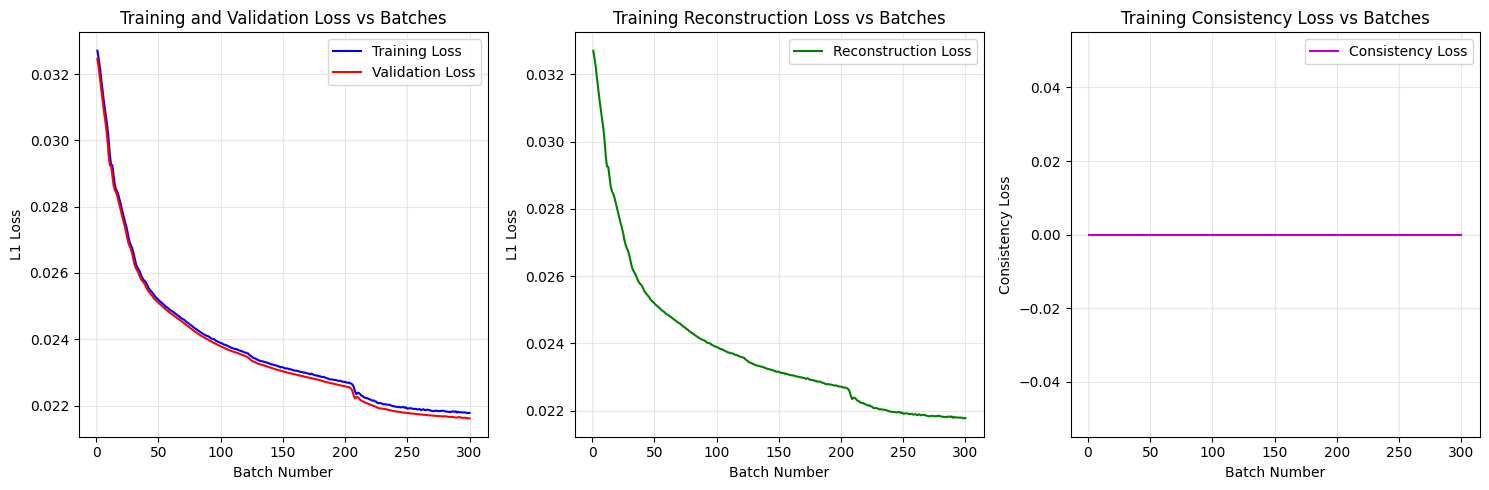

In [22]:
# Train the model using the fixed training function
print("\n" + "="*80)
print("Training attention model on transcriptomics...")
print("="*80 + "\n")

history_transcriptomics = train_attention_model(
    model=model_transcriptomics,
    train_dataset=train_dataset_transcriptomics,
    val_dataset=val_dataset_transcriptomics,
    config=CONFIG_TRANSCRIPTOMICS,
    device=device
)

# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_losses'], 'b-', label='Training Loss')
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['val_losses'], 'r-', label='Validation Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training and Validation Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_recon_losses'], 'g-', label='Reconstruction Loss')
plt.xlabel('Batch Number')
plt.ylabel('L1 Loss')
plt.title('Training Reconstruction Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history_transcriptomics['batch_numbers'], history_transcriptomics['train_consist_losses'], 'm-', label='Consistency Loss')
plt.xlabel('Batch Number')
plt.ylabel('Consistency Loss')
plt.title('Training Consistency Loss vs Batches')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization of Learned Attention Matrices

Now we visualize the learned attention patterns. The attention weights represent our learned "connectome" - how much each neuron needs to attend to every other neuron for reconstruction. We'll focus on analyzing the structure and patterns in the learned attention matrix.


In [23]:
# Updated analyze_attention_matrix function with dictionary unpacking
def analyze_attention_matrix(model, dataset, neuron_labels, device, 
                            use_attention_scores=False, sparsity_thresh=0.1,
                            num_graph_sources=10):
    """
    Extract and comprehensively analyze learned attention matrix.
    
    Args:
        model: trained SingleHeadSelfAttention or DeepConnectomeTransformer model
        dataset: Dataset used for evaluation
        neuron_labels: list of neuron identifiers, must exactly correspond to order of rows in dataset
        device: torch device
        use_attention_scores: whether to use scores or weights
        sparsity_thresh: weight threshold for sparsity calculation and edges in graph visualization
        num_graph_sources: number of source neurons to highlight for graph visualization
    
    Returns:
        dict with attention matrix and comprehensive analysis results
    """
    model.eval()
    
    # Collect attention matrices from all samples
    all_attn_weights = []
    all_attn_scores = []
    loader = DataLoader(dataset, batch_size=32, shuffle=False)
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # Use dictionary unpacking
            outputs = model(batch, attn_dropout=0.0)
            attn_weights = outputs['attn_weights']
            attn_scores = outputs['attn_scores']
            all_attn_weights.append(attn_weights.clone().cpu().numpy())
            all_attn_scores.append(attn_scores.clone().cpu().numpy())
    
    # We will average across all samples
    all_attn_weights = np.concatenate(all_attn_weights, axis=0)
    all_attn_scores = np.concatenate(all_attn_scores, axis=0)
    
    # Take mean across batch dimension; shape (num_neurons, num_neurons)
    attention_weights_matrix = np.mean(all_attn_weights, axis=0)
    attention_scores_matrix = np.mean(all_attn_scores, axis=0)
    
    # Choose which matrix to analyze
    if use_attention_scores:
        attention_matrix = attention_scores_matrix
        matrix_type = "scores"
    else:
        attention_matrix = attention_weights_matrix
        matrix_type = "weights"
    
    # Assert that matrix dimensions match number of neuron labels
    assert attention_matrix.shape[0] == len(neuron_labels), \
        f"Number of rows in attention matrix ({attention_matrix.shape[0]}) " \
        f"does not match number of neuron labels ({len(neuron_labels)})"
    
    # Basic statistics
    mean_val = np.mean(attention_matrix)
    std_val = np.std(attention_matrix)
    max_val = np.max(attention_matrix)
    # Use the weights matrix for sparsity calculation
    sparsity = np.sum(attention_weights_matrix < sparsity_thresh) / attention_weights_matrix.size 
    
    # Create visualization with 4 panels
    fig = plt.figure(figsize=(24, 18))
    
    # Create grid with two rows
    gs = plt.GridSpec(2, 2, height_ratios=[1.2, 0.8])
    
    # 1) Full attention matrix heatmap - larger and square (top left)
    ax1 = plt.subplot(gs[0, 0])
    im1 = ax1.imshow(attention_matrix, cmap='viridis', aspect='equal')
    ax1.set_title(f'Learned Attention Matrix ({matrix_type.title()})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Source Neuron', fontsize=12)
    ax1.set_ylabel('Target Neuron', fontsize=12)
    # Set tick labels to neuron labels with larger font size
    ax1.set_xticks(np.arange(len(neuron_labels)))
    ax1.set_yticks(np.arange(len(neuron_labels)))
    ax1.set_xticklabels(neuron_labels, rotation=90, ha='right', fontsize=8)
    ax1.set_yticklabels(neuron_labels, fontsize=8)
    plt.colorbar(im1, ax=ax1, label=f'Attention {matrix_type.title()}')
    
    # 2) Network graph visualization (top right)
    ax2 = plt.subplot(gs[0, 1])
    G = nx.DiGraph()
    n_neurons = len(neuron_labels)
    
    # Add nodes
    for i, label in enumerate(neuron_labels):
        G.add_node(i, label=label)
    
    # Add edges above threshold
    edge_thresh = sparsity_thresh
    for i in range(n_neurons):  # i is target
        for j in range(n_neurons):  # j is source
            if attention_weights_matrix[i, j] > edge_thresh:
                G.add_edge(j, i, weight=attention_matrix[i, j])
    
    # Select top source neurons
    outgoing_attention = np.sum(attention_weights_matrix, axis=0)
    top_sources = np.argsort(outgoing_attention)[-num_graph_sources:]
    
    # Create subgraph
    subgraph_nodes = set(top_sources)
    for source in top_sources:
        targets = np.where(attention_weights_matrix[:, source] > edge_thresh)[0]
        subgraph_nodes.update(targets)

    subgraph = G.subgraph(subgraph_nodes)
    
    # Layout and draw
    pos = nx.spring_layout(subgraph, k=1, iterations=50)
    node_colors = ['red' if node in top_sources else 'lightblue' for node in subgraph.nodes()]
    
    nx.draw(subgraph, pos, ax=ax2, 
            node_color=node_colors,
            node_size=500,
            with_labels=True,
            labels={node: neuron_labels[node] for node in subgraph.nodes()},
            font_size=8,
            font_weight='bold',
            edge_color='gray',
            alpha=0.7)
    ax2.set_title(f'Attention Network (Top {num_graph_sources} Sources)', fontsize=14, fontweight='bold')
    
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Top Source',
                                 markerfacecolor='red', markersize=10),
                      plt.Line2D([0], [0], marker='o', color='w', label='Other Neuron',
                                 markerfacecolor='lightblue', markersize=10)]
    ax2.legend(handles=legend_elements, loc='upper right')
    
    # 3) Attention distribution (bottom left)
    ax3 = plt.subplot(gs[1, 0])
    ax3.hist(attention_matrix.flatten(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    ax3.set_title(f'Attention {matrix_type.title()} Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel(f'Attention {matrix_type.title()}', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.axvline(sparsity_thresh, color='red', linestyle='--', label=f'Sparsity threshold ({sparsity_thresh})')
    ax3.legend()
    
    # 4) Summary statistics text box (bottom right)
    ax4 = plt.subplot(gs[1, 1])
    ax4.axis('off')
    summary_text = f"""Attention Matrix Summary:

    Matrix Type: {matrix_type.title()}
    Shape: {attention_matrix.shape}
    Mean: {mean_val:.6f}
    Std: {std_val:.6f}
    Max: {max_val:.6f}
    Sparsity (< Threshold = {sparsity_thresh}): {sparsity:.3f}

    Network Statistics:
    Total Nodes: {len(subgraph.nodes())}
    Total Edges: {len(subgraph.edges())}
    Top Sources: {num_graph_sources}
    Edge Threshold (= Sparsity Threshold): {edge_thresh}

    Neuron Labels: {len(neuron_labels)}"""
    
    ax4.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    return {
        'attention_matrix': attention_matrix,
        'attention_weights': attention_weights_matrix,
        'attention_scores': attention_scores_matrix,
        'mean': mean_val,
        'std': std_val,
        'max': max_val,
        'sparsity': sparsity,
        'network': subgraph,
        'top_sources': top_sources
    }


Analyzing learned attention matrix from transcriptomics phase...


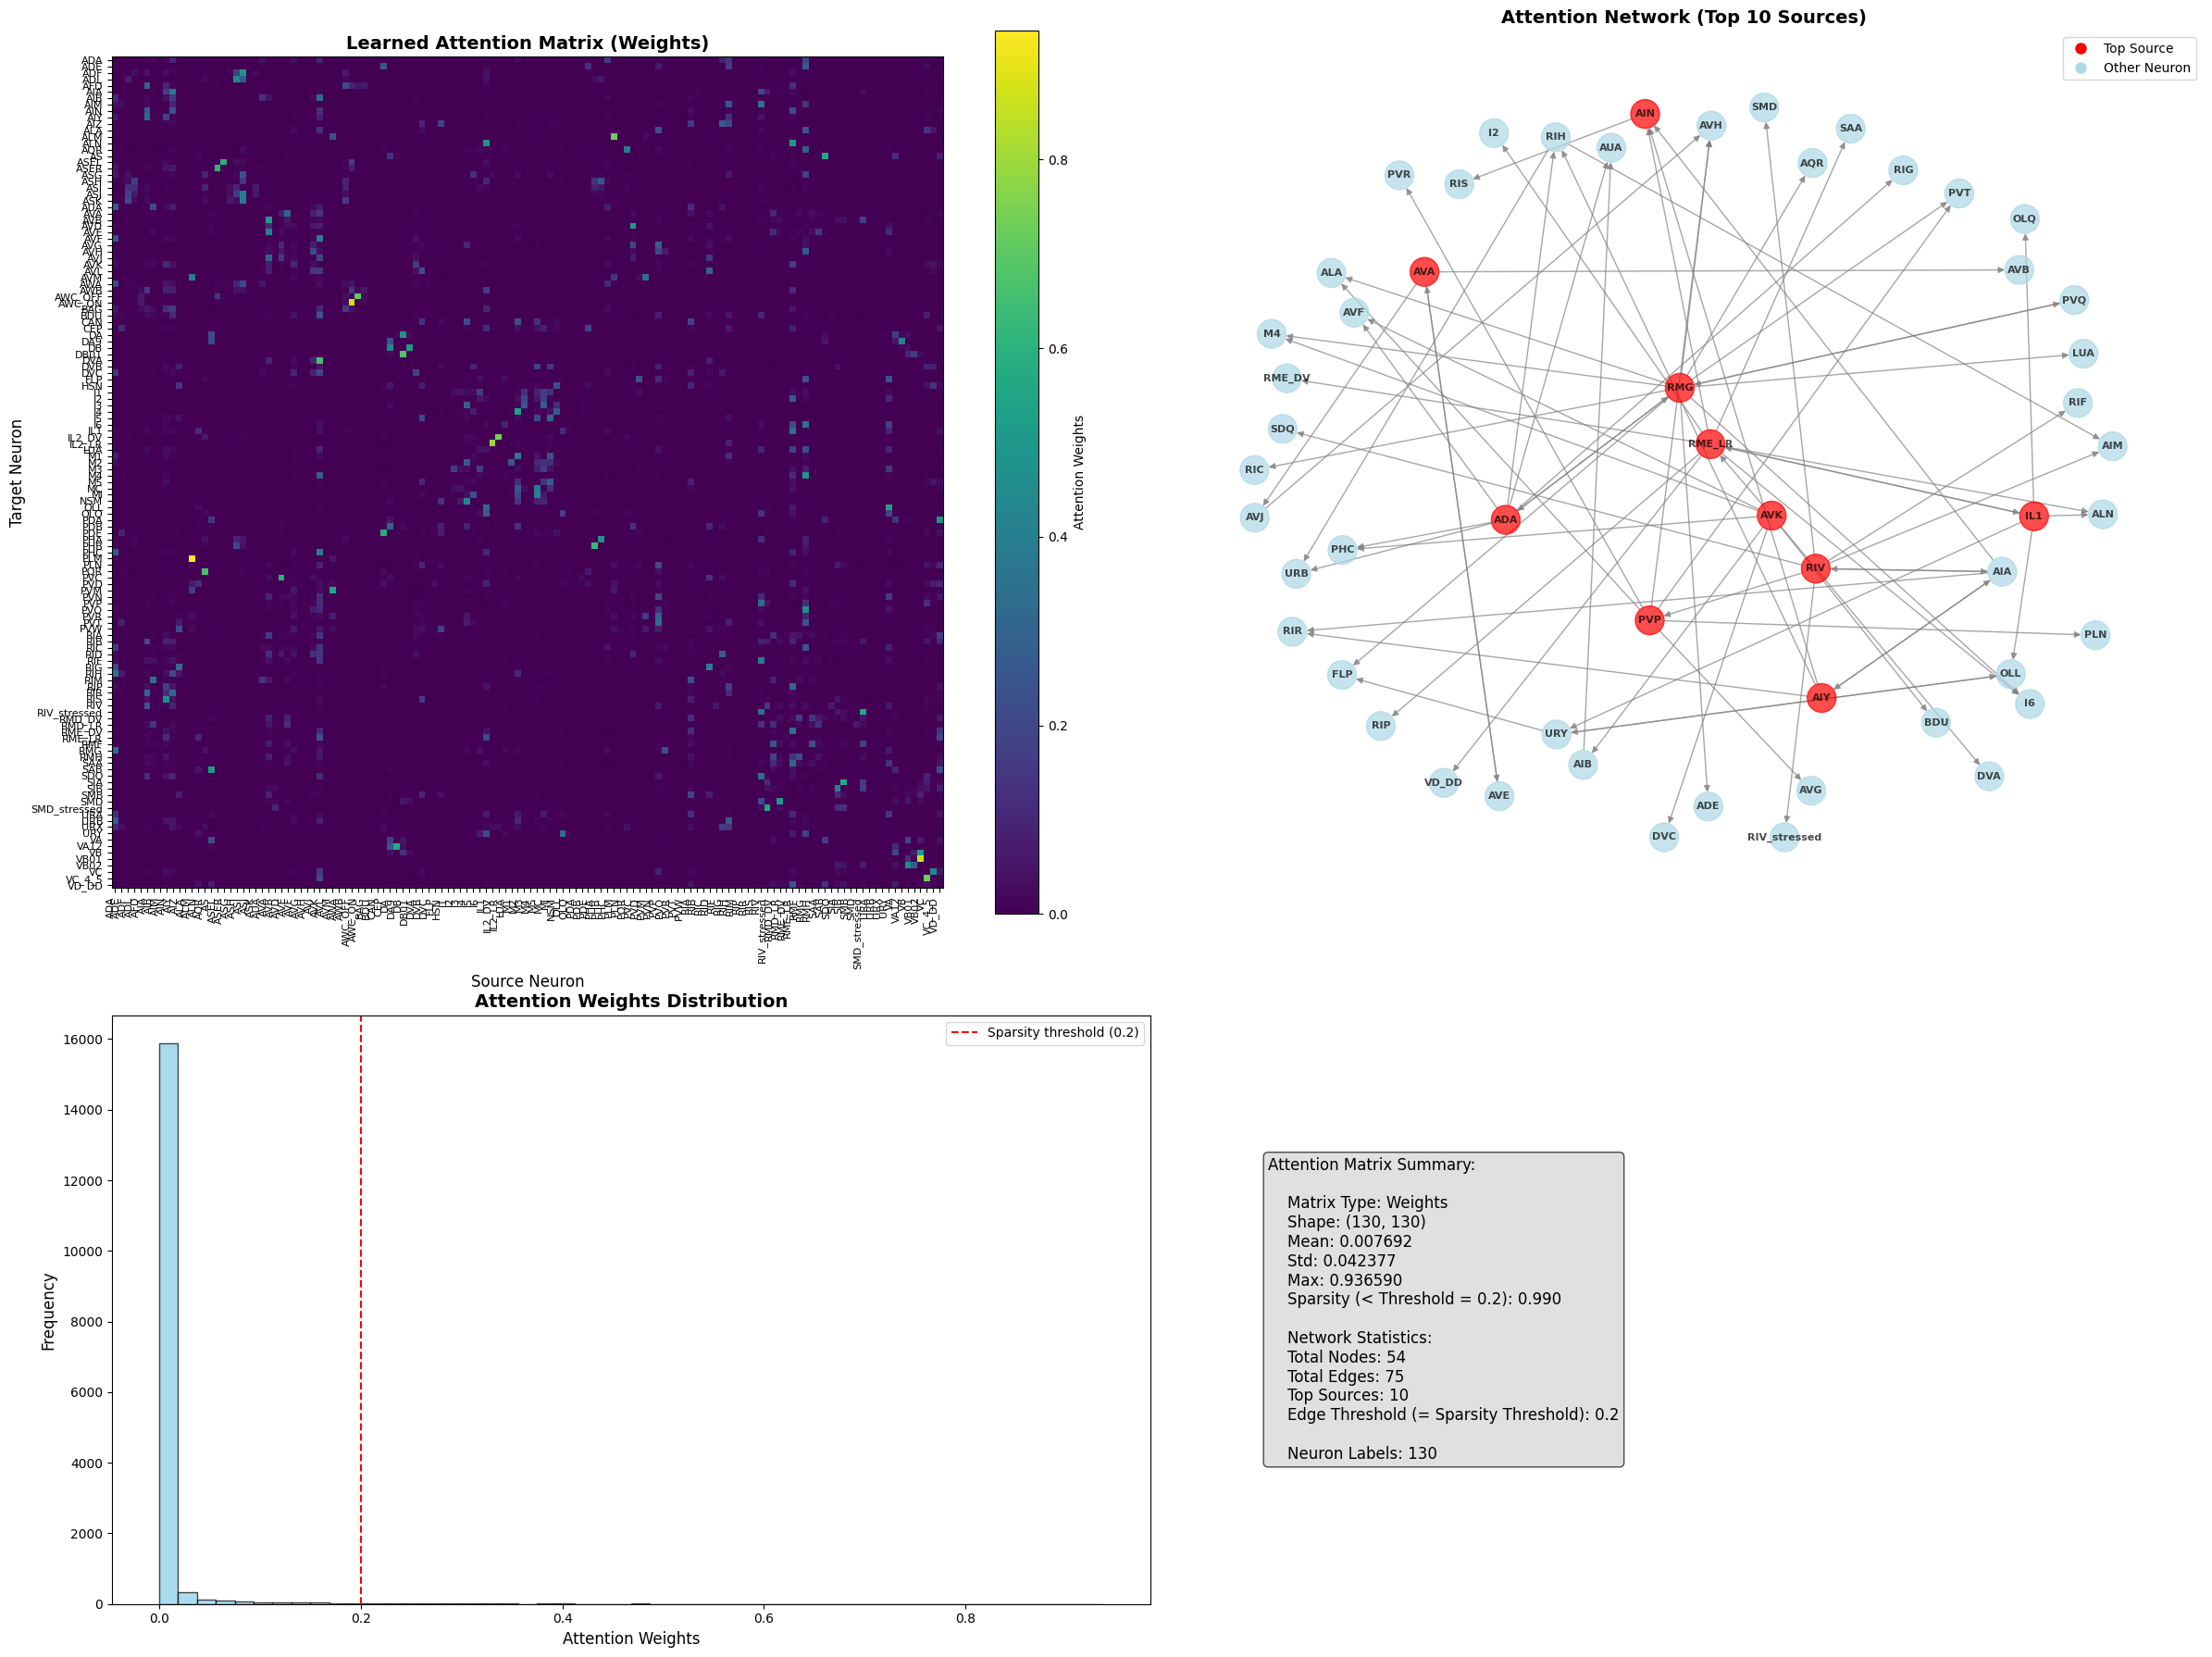


Transcriptomics Phase Results:
  Attention matrix shape: (130, 130)
  Sparsity: 0.990
  Mean attention weight: 0.007692
  Std attention weight: 0.042377


In [24]:
# Replace the transcriptomics visualization with modularized function
print("Analyzing learned attention matrix from transcriptomics phase...")

# Analyze using the comprehensive function
analysis_results_transcriptomics = analyze_attention_matrix(
    model=model_transcriptomics,
    dataset=val_dataset_transcriptomics, # test_dataset
    neuron_labels=neuron_labels_transcriptomics,
    device=device,
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    sparsity_thresh=0.2,
    num_graph_sources=10,
)

attention_weights_transcriptomics = analysis_results_transcriptomics['attention_weights']
attention_scores_transcriptomics = analysis_results_transcriptomics['attention_scores']

print(f"\nTranscriptomics Phase Results:")
print(f"  Attention matrix shape: {analysis_results_transcriptomics['attention_matrix'].shape}")
print(f"  Sparsity: {analysis_results_transcriptomics['sparsity']:.3f}")
print(f"  Mean attention weight: {analysis_results_transcriptomics['mean']:.6f}")
print(f"  Std attention weight: {analysis_results_transcriptomics['std']:.6f}")


### **Idea**: Does the learned attention matrix better embed neurons? 

If we interpret the attention matrix as a similarity matrix, does it induce a semantically meaningful clustering of neurons, such as by cell-type or neurotransmitters?

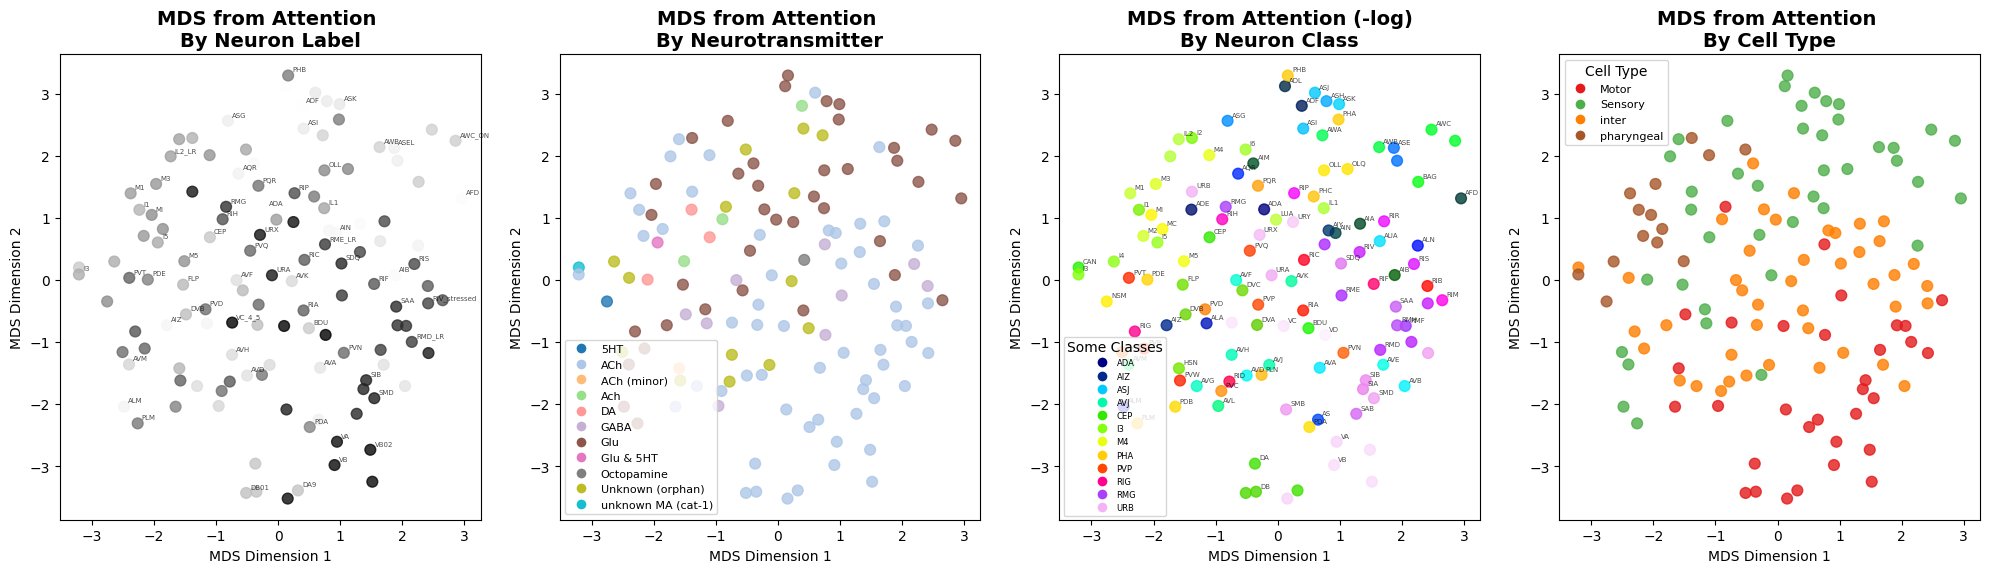

In [25]:
# Simple approach: treat learned attention matrix as similarity, 
# turn into distance, and use sklearn MDS.

# Use the learned attention matrix as similarity
attention = analysis_results_transcriptomics['attention_matrix'].copy()

# Restore diagonal to 1s (since diagonal was masked out during attention calculation)
np.fill_diagonal(attention, 1.0)

# Optional: symmetrize if desired (can comment out if already symmetric)
attention_similarity = np.clip(0.5 * (attention + attention.T), 0, 1)

# Convert similarity to distance; use information distance, which is steeper than sqrt(1-S)
eps = 1e-9   
attention_dissimilarity = np.sqrt(np.maximum(0.0, -np.log(attention_similarity + eps)))  # shape (N, N)

# Now run MDS. We use "precomputed" because we give the distance matrix.
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords_mds = mds.fit_transform(attention_dissimilarity)   # shape (N,2)

# Plot: 4 panel fig, colored by (1) neuron label, (2) neurotransmitter, (3) class, (4) cell type
fig, axes = plt.subplots(1, 4, figsize=(20, 15))

# Prepare color maps
unique_nt = np.sort(np.unique(neuron_neurotransmitters))
nt_to_color = {nt: i/len(unique_nt) for i, nt in enumerate(unique_nt)}
unique_cls = np.sort(np.unique(neuron_classes))
cls_to_color = {cls: i/len(unique_cls) for i, cls in enumerate(unique_cls)}
unique_types = np.sort(np.unique(neuron_types))
type_to_color = {ntype: i/len(unique_types) for i, ntype in enumerate(unique_types)}

label_cmap = plt.cm.Greys
nt_cmap = plt.cm.tab20
cls_cmap = plt.cm.gist_ncar
type_cmap = plt.cm.Set1

# Plot 1: colored by neuron label (index)
ax = axes[0]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                     c=range(len(neuron_labels_transcriptomics)), cmap=label_cmap, s=60, alpha=0.8)
ax.set_title('MDS from Attention \nBy Neuron Label', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')

for i in range(0, len(neuron_labels_transcriptomics), 2):
    ax.annotate(neuron_labels_transcriptomics[i],
                (coords_mds[i, 0], coords_mds[i, 1]),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5, alpha=0.7)

# Plot 2: colored by neurotransmitter
ax = axes[1]
colors = [nt_cmap(nt_to_color[nt]) for nt in neuron_neurotransmitters]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('MDS from Attention \nBy Neurotransmitter', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=nt_cmap(nt_to_color[nt]),
                      markersize=8, label=nt) for nt in unique_nt]
ax.legend(handles=handles, loc='best', fontsize=8)

# Plot 3: colored by neuron class, text annotations for each class
ax = axes[2]
colors = [cls_cmap(cls_to_color[cls]) for cls in neuron_classes]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('MDS from Attention (-log)\nBy Neuron Class', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')

k = len(unique_cls) // 12 + 1
selected_classes = unique_cls[::k]
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=cls_cmap(cls_to_color[cls]),
                      markersize=8, label=cls) for cls in selected_classes]
ax.legend(handles=handles, loc='best', fontsize=6, title='Some Classes')

for cls in unique_cls:
    cls_indices = np.where(neuron_classes == cls)[0]
    if len(cls_indices) > 0:
        idx = cls_indices[0]
        ax.annotate(cls,
                    (coords_mds[idx, 0], coords_mds[idx, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=5, alpha=0.7)

# Plot 4: colored by cell type
ax = axes[3]
colors = [type_cmap(type_to_color[ntype]) for ntype in neuron_types]
scatter = ax.scatter(coords_mds[:, 0], coords_mds[:, 1], c=colors, s=60, alpha=0.8)
ax.set_title('MDS from Attention \nBy Cell Type', fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1')
ax.set_ylabel('MDS Dimension 2')
ax.set_aspect('equal')
handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=type_cmap(type_to_color[ntype]),
                      markersize=8, label=ntype) for ntype in unique_types]
ax.legend(handles=handles, loc='best', fontsize=8, title='Cell Type')

plt.tight_layout()
plt.show()


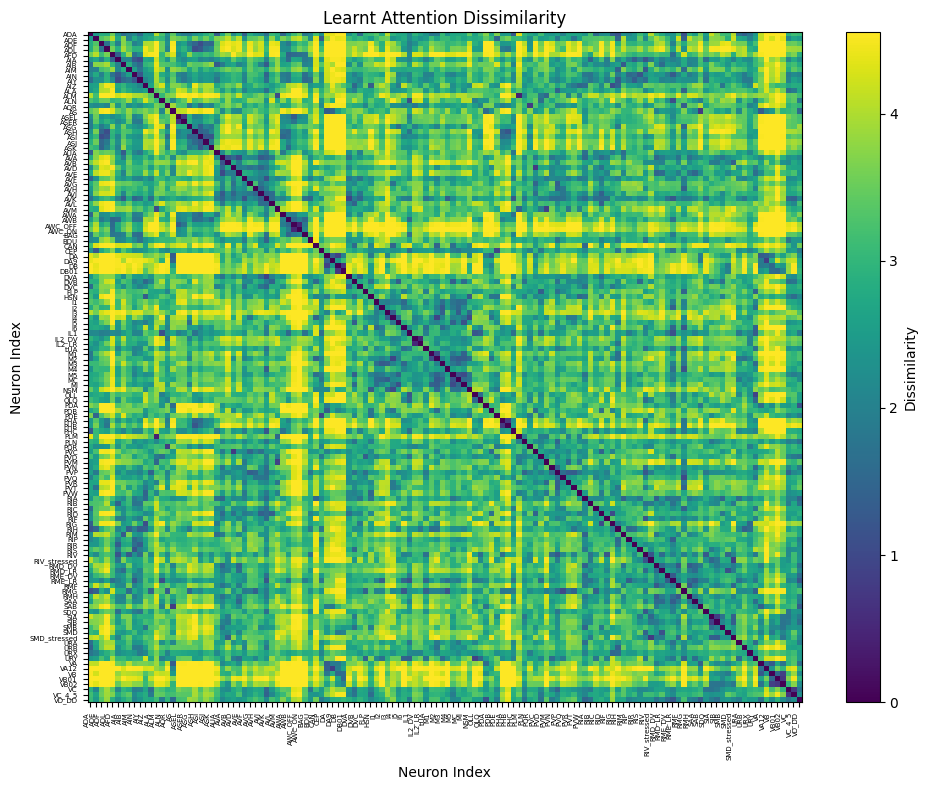

In [26]:
plt.figure(figsize=(10, 8))
plt.imshow(attention_dissimilarity, cmap='viridis', aspect='auto')
plt.colorbar(label='Dissimilarity')
plt.xlabel('Neuron Index')
plt.ylabel('Neuron Index')
plt.xticks(range(len(neuron_labels_transcriptomics)), neuron_labels_transcriptomics, rotation=90, ha='right', fontsize=5)
plt.yticks(range(len(neuron_labels_transcriptomics)), neuron_labels_transcriptomics, fontsize=5)
plt.title('Learnt Attention Dissimilarity')
plt.tight_layout()

## Ground-Truth Connectome Data Loading and Analysis

Now we'll load and analyze ground-truth connectome data to compare with our learned attention matrix. We have access to:

1. **Witvliet 2020 data** (`witvliet_2020_7.csv`, `witvliet_2020_8.csv`): From "Connectomes across development reveal principles of brain maturation" (Nature 596, 257–261, 2021)
2. **Cook 2019 data** (`41586_2019_1352_MOESM9_ESM.xlsx`): From "Whole-animal connectomes of both Caenorhabditis elegans sexes" (Nature 571, 63–71, 2019)
3. **Randi 2023 data** (`CElegansFunctionalConnectivity.xlsx`): From "Neural signal propagation atlas of Caenorhabditis elegans" (Nature 623, 406–414, 2023)

These provide both structural (wired) and functional connectivity data that we can compare against our learned attention patterns.

### References
> Witvliet, D., Mulcahy, B., Mitchell, J.K. et al. Connectomes across development reveal principles of brain maturation. Nature 596, 257–261 (2021). https://doi.org/10.1038/s41586-021-03778-8

> Cook, S.J., Jarrell, T.A., Brittin, C.A. et al. Whole-animal connectomes of both Caenorhabditis elegans sexes. Nature 571, 63–71 (2019). https://doi.org/10.1038/s41586-019-1352-7

> Randi, F., Sharma, A.K., Dvali, S. et al. Neural signal propagation atlas of Caenorhabditis elegans. Nature 623, 406–414 (2023). https://doi.org/10.1038/s41586-023-06683-4


In [32]:
# Load and analyze Witvliet 2020 connectome data
print("Loading Witvliet 2020 connectome data...")

# Load both datasets (they are tab-separated)
witvliet_7 = pd.read_csv('data/connectomics/witvliet_2020_7.csv', sep='\t')
witvliet_8 = pd.read_csv('data/connectomics/witvliet_2020_8.csv', sep='\t')

print(f"Witvliet 2020-7 shape: {witvliet_7.shape}")
print(f"Witvliet 2020-8 shape: {witvliet_8.shape}")
print(f"\nWitvliet 2020-7 columns: {witvliet_7.columns.tolist()}")
print(f"Witvliet 2020-8 columns: {witvliet_8.columns.tolist()}")

# Display sample data
print(f"\nWitvliet 2020-7 sample:")
print(witvliet_7.head())
print(f"\nWitvliet 2020-8 sample:")
print(witvliet_8.head())

# Analyze unique neurons in each dataset, filtering out BWM (body-wall muscle) neurons
neurons_7_pre = {n for n in witvliet_7['pre'].unique() if not n.startswith('BWM-')}
neurons_7_post = {n for n in witvliet_7['post'].unique() if not n.startswith('BWM-')}
neurons_7_all = neurons_7_pre.union(neurons_7_post)

neurons_8_pre = {n for n in witvliet_8['pre'].unique() if not n.startswith('BWM-')}
neurons_8_post = {n for n in witvliet_8['post'].unique() if not n.startswith('BWM-')}
neurons_8_all = neurons_8_pre.union(neurons_8_post)

# Union of all neurons across both datasets
neurons_7_8_all = neurons_7_all.union(neurons_8_all)

# Map class members to their class names since the neuron labels consist of a mixture of class and members
neurons_7_8_all |= {label_to_class[mem] for mem in neurons_7_8_all if mem in label_to_class}  

# Sort for consistent ordering
neurons_7_8_all = sorted(list(neurons_7_8_all))  

print(f"\nNeuron analysis:")
print(f"Witvliet 2020-7: {len(neurons_7_all)} unique neurons")
print(f"Witvliet 2020-8: {len(neurons_8_all)} unique neurons")
print(f"Union of Witvliet 2020-7 and 2020-8: {len(neurons_7_8_all)} neurons")


Loading Witvliet 2020 connectome data...
Witvliet 2020-7 shape: (2493, 4)
Witvliet 2020-8 shape: (2496, 4)

Witvliet 2020-7 columns: ['pre', 'post', 'type', 'synapses']
Witvliet 2020-8 columns: ['pre', 'post', 'type', 'synapses']

Witvliet 2020-7 sample:
    pre  post      type  synapses
0  ADAL  AIAL  chemical         2
1  ADAL  AIBL  chemical         2
2  ADAL  AIBR  chemical         1
3  ADAL  AVAL  chemical         1
4  ADAL  AVBL  chemical         7

Witvliet 2020-8 sample:
    pre  post        type  synapses
0  ADAL  ADAR  electrical         1
1  ADAL  ASHL  electrical         1
2  ADAL  AVAL    chemical         2
3  ADAL  AVAR    chemical         1
4  ADAL  AVBL    chemical        16

Neuron analysis:
Witvliet 2020-7: 190 unique neurons
Witvliet 2020-8: 187 unique neurons
Union of Witvliet 2020-7 and 2020-8: 260 neurons


In [186]:
# ============================================================================
# MODULARIZED MATRIX COMPARISON AND VISUALIZATION FUNCTIONS
# ============================================================================

def create_adjacency_matrix(connectome_df, neuron_list, weight_col='synapses', synapse_type='electrical'):
    """
    Create adjacency matrix from connectome dataframe.

    Args:
        connectome_df: DataFrame with columns ['pre', 'post', 'type', 'weight']
        neuron_list: List of neuron names in desired order
        weight_col: Column name for edge weights
        synapse_type: Type of synapse to include ('chemical', 'electrical', 'all')

    Returns:
        adjacency_matrix: (N, N) numpy array
    """
    n_neurons = len(neuron_list)
    adjacency_matrix = np.zeros((n_neurons, n_neurons))

    # Create mapping from neuron name to index
    neuron_to_idx = {neuron: i for i, neuron in enumerate(neuron_list)}

    # Filter by synapse type
    if synapse_type != 'all':
        filtered_df = connectome_df[connectome_df['type'] == synapse_type]
    else:
        filtered_df = connectome_df

    # Fill adjacency matrix
    for _, row in filtered_df.iterrows():
        pre_neuron = row['pre']
        post_neuron = row['post']
        syn_type = row['type']
        weight = row[weight_col]

        if pre_neuron in neuron_to_idx and post_neuron in neuron_to_idx:
            pre_idx = neuron_to_idx[pre_neuron]
            post_idx = neuron_to_idx[post_neuron]
            adjacency_matrix[pre_idx, post_idx] += weight
            # Ensure symmetry for electrical (gap junctions)
            if syn_type == 'electrical' and pre_idx != post_idx:
                adjacency_matrix[post_idx, pre_idx] += weight

    return adjacency_matrix


In [201]:
# Analyze connection types
print(f"\nConnection type analysis:")
print(f"Witvliet 2020-7 types: {witvliet_7['type'].value_counts().to_dict()}")
print(f"Witvliet 2020-8 types: {witvliet_8['type'].value_counts().to_dict()}")

# Create full adjacency matrices for all neurons in union (choose synapse type)
synapse_type = 'electrical' # Options: 'electrical', 'chemical', 'all'
print(f"\nCreating adjacency matrices for {len(neurons_7_8_all)} neurons...")

print("Witvliet 2020-7:")
gt_adj_7_full = create_adjacency_matrix(witvliet_7, neurons_7_8_all, weight_col='synapses', synapse_type=synapse_type)

print("Witvliet 2020-8:")
gt_adj_8_full = create_adjacency_matrix(witvliet_8, neurons_7_8_all, weight_col='synapses', synapse_type=synapse_type)

# Average element-wise (treating missing connections as 0)
gt_adj_combined = (gt_adj_7_full + gt_adj_8_full) / 2

# # Add small epsilon to avoid division by zero, similar to attention masking
# eps = 1e-9
# row_sums = gt_adj_combined.sum(axis=1, keepdims=True) + eps
# gt_adj_combined = gt_adj_combined / row_sums

print(f"\nCombined adjacency matrix shape: {gt_adj_combined.shape}")
print(f"Combined matrix stats - mean: {gt_adj_combined.mean():.6f}, std: {gt_adj_combined.std():.6f}, max: {gt_adj_combined.max():.1f}")



Connection type analysis:
Witvliet 2020-7 types: {'chemical': 2202, 'electrical': 291}
Witvliet 2020-8 types: {'chemical': 2186, 'electrical': 310}

Creating adjacency matrices for 260 neurons...
Witvliet 2020-7:
Witvliet 2020-8:

Combined adjacency matrix shape: (260, 260)
Combined matrix stats - mean: 0.011694, std: 0.129576, max: 5.0


In [202]:
def compare_attention_with_ground_truth(attention_matrix, attention_neuron_labels, 
                                     ground_truth_matrices, ground_truth_neuron_labels,
                                     phase_name="Unknown Phase", 
                                     label_to_class_mapping=None,
                                     exclude_bwm=True):
    """
    Comprehensive comparison between learned attention matrix and ground-truth connectomes.
    
    Args:
        attention_matrix: (N, N) learned attention matrix
        attention_neuron_labels: List of neuron labels for attention matrix
        ground_truth_matrices: Dict of {'name': matrix} for ground-truth connectomes
        ground_truth_neuron_labels: Dict of {'name': labels} for ground-truth matrices
        phase_name: String describing the phase (e.g., "Transcriptomics", "Neural Dynamics")
        label_to_class_mapping: Optional dict mapping neuron labels to class names
        exclude_bwm: Whether to exclude BWM (body-wall muscle) neurons
    
    Returns:
        results: Dict containing comparison results and visualizations
    """
    print(f"\n" + "="*80)
    print(f"Comparing Ground-Truth Connectome to Learned Attention Matrix ({phase_name.upper()})")
    print("="*80)
    
    results = {
        'phase_name': phase_name,
        'attention_matrix': attention_matrix,
        'attention_neuron_labels': attention_neuron_labels,
        'comparisons': {}
    }
    
    # Process attention neuron labels
    if exclude_bwm:
        attention_neurons = {n for n in attention_neuron_labels if not n.startswith('BWM-')}
    else:
        attention_neurons = set(attention_neuron_labels)
    
    # Apply label-to-class mapping if provided
    if label_to_class_mapping:
        attention_neurons |= {label_to_class_mapping[mem] for mem in attention_neurons 
                             if mem in label_to_class_mapping}
    
    # Compare with each ground-truth connectome
    for gt_name, gt_matrix in ground_truth_matrices.items():
        print(f"\n{'='*60}")
        print(f"Comparing {gt_name.upper()} Connectome to Attention Matrix")
        print(f"{'='*60}")
        
        gt_labels = ground_truth_neuron_labels[gt_name]
        
        # Process ground-truth neuron labels
        if exclude_bwm:
            gt_neurons = {n for n in gt_labels if not n.startswith('BWM-')}
        else:
            gt_neurons = set(gt_labels)
        
        # Apply label-to-class mapping if provided
        if label_to_class_mapping:
            gt_neurons |= {label_to_class_mapping[mem] for mem in gt_neurons 
                          if mem in label_to_class_mapping}
        
        # Find overlapping neurons
        overlap_neurons = sorted(list(attention_neurons.intersection(gt_neurons).intersection(attention_neuron_labels).intersection(gt_labels)))
        if len(overlap_neurons) == 0:
            raise ValueError(f"⚠️  No overlapping neurons found with {gt_name}")
        
        print(f"Attention neurons: {len(attention_neurons)}")
        print(f"Ground-truth neurons: {len(gt_neurons)}")
        print(f"Overlapping neurons: {len(overlap_neurons)}")
        print(f"Overlap percentage: {len(overlap_neurons) / max(len(attention_neurons), len(gt_neurons)) * 100:.1f}%")
            
        # Get indices for attention matrix
        attention_indices = [attention_neuron_labels.index(n) for n in overlap_neurons if n in attention_neuron_labels]
        
        # Get indices for ground-truth matrix
        gt_indices = [gt_labels.index(n) for n in overlap_neurons if n in gt_labels]
        
        # Extract submatrices
        attention_submatrix = attention_matrix[np.ix_(attention_indices, attention_indices)]
        gt_submatrix = gt_matrix[np.ix_(gt_indices, gt_indices)]
        
        print(f"Full matrix shapes: Attention {attention_matrix.shape}, GT {gt_matrix.shape}")
        print(f"Submatrix shapes: Attention {attention_submatrix.shape}, GT {gt_submatrix.shape}")

        # Verify shapes match
        if attention_submatrix.shape != gt_submatrix.shape:
            raise ValueError("⚠️ Error: Submatrix shapes do not match!")
        
        # Flatten matrices and remove diagonal
        mask = ~np.eye(attention_submatrix.shape[0], dtype=bool)
        attn_flat = attention_submatrix[mask]
        gt_flat = gt_submatrix[mask]
        
        # Remove any NaN values
        valid_mask = ~(np.isnan(attn_flat) | np.isnan(gt_flat))
        attn_valid = attn_flat[valid_mask]
        gt_valid = gt_flat[valid_mask]
        
        if len(attn_valid) > 1:
            correlation, p_value = pearsonr(attn_valid, gt_valid)
        else:
            correlation, p_value = np.nan, np.nan
        
        print(f"Correlation: r = {correlation:.4f}, p = {p_value:.2e}")
        print(f"Valid data points: {len(attn_valid)}/{len(attn_flat)}")
        
        # Store results
        results['comparisons'][gt_name] = {
            'overlap_count': len(overlap_neurons),
            'correlation': correlation,
            'p_value': p_value,
            'overlap_neurons': overlap_neurons,
            'attention_submatrix': attention_submatrix,
            'gt_submatrix': gt_submatrix,
            'valid_data_points': len(attn_valid)
        }
        
        # Plot submatrix comparison
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # Ground truth submatrix
        im1 = ax1.imshow(gt_submatrix, cmap='viridis', aspect='auto')
        ax1.set_title(f'Ground Truth Submatrix\n({gt_name})', fontsize=12)
        plt.colorbar(im1, ax=ax1, label='Synapse Count')
        
        # Attention submatrix  
        im2 = ax2.imshow(attention_submatrix, cmap='plasma', aspect='auto')
        ax2.set_title(f'Attention Submatrix\n({len(overlap_neurons)} neurons)', fontsize=12)
        plt.colorbar(im2, ax=ax2, label='Attention Weight')
        
        # Add neuron labels
        for ax in [ax1, ax2]:
            ax.set_xticks(range(len(overlap_neurons)))
            ax.set_xticklabels(overlap_neurons, rotation=90, fontsize=5)
            ax.set_yticks(range(len(overlap_neurons))) 
            ax.set_yticklabels(overlap_neurons, fontsize=5)
            
        plt.tight_layout()
        plt.show()
    
    # Print comprehensive statistics
    print(f"\n" + "="*60)
    print(f"Matrix Statistics: {phase_name.upper()}")
    print("="*60)
    
    print(f"\nLearned Attention Matrix:")
    print(f"  Shape: {attention_matrix.shape}")
    print(f"  Mean: {attention_matrix.mean():.6f}")
    print(f"  Std: {attention_matrix.std():.6f}")
    print(f"  Max: {attention_matrix.max():.6f}")
    print(f"  Sparsity: {(attention_matrix < 0.01).sum() / attention_matrix.size:.3f}")
    
    for gt_name, comparison in results['comparisons'].items():
        if comparison['overlap_count'] == 0:
            continue
            
        print(f"\n{gt_name.upper()} Comparison:")
        print(f"  Overlapping neurons: {comparison['overlap_count']}")
        print(f"  Correlation: r = {comparison['correlation']:.4f}")
        print(f"  P-value: {comparison['p_value']:.2e}")
        print(f"  Valid data points: {comparison['valid_data_points']}")
        
        if 'gt_submatrix' in comparison:
            gt_sub = comparison['gt_submatrix']
            print(f"  GT submatrix - Mean: {gt_sub.mean():.6f}, Std: {gt_sub.std():.6f}, Max: {gt_sub.max():.1f}")
            print(f"  GT submatrix - Sparsity: {(gt_sub == 0).sum() / gt_sub.size:.3f}")
            
    return results


Comparing Ground-Truth Connectome to Learned Attention Matrix (TRANSCRIPTOMICS)

Comparing WITVLIET_COMBINED Connectome to Attention Matrix
Attention neurons: 131
Ground-truth neurons: 260
Overlapping neurons: 78
Overlap percentage: 30.0%
Full matrix shapes: Attention (130, 130), GT (260, 260)
Submatrix shapes: Attention (78, 78), GT (78, 78)
Correlation: r = -0.0037, p = 7.75e-01
Valid data points: 6006/6006


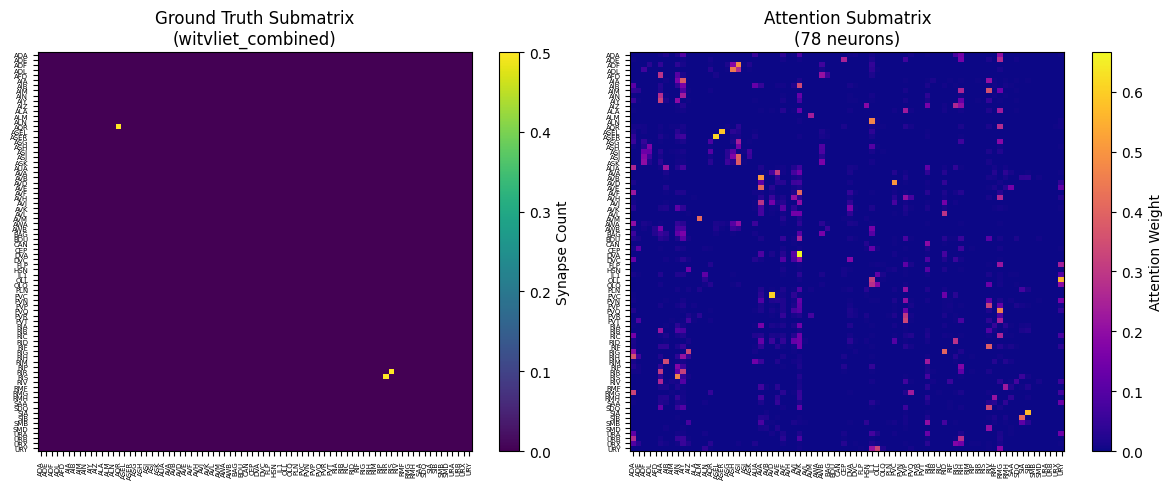


Matrix Statistics: TRANSCRIPTOMICS

Learned Attention Matrix:
  Shape: (130, 130)
  Mean: 0.007692
  Std: 0.042377
  Max: 0.936590
  Sparsity: 0.920

WITVLIET_COMBINED Comparison:
  Overlapping neurons: 78
  Correlation: r = -0.0037
  P-value: 7.75e-01
  Valid data points: 6006
  GT submatrix - Mean: 0.000247, Std: 0.011100, Max: 0.5
  GT submatrix - Sparsity: 1.000


In [203]:
# Comprehensive Matrix Visualization: Full vs Submatrices
comparison_results_transcriptomics = compare_attention_with_ground_truth(
    attention_matrix=attention_weights_transcriptomics,
    attention_neuron_labels=neuron_labels_transcriptomics,
    ground_truth_matrices=dict(witvliet_combined=gt_adj_combined),
    ground_truth_neuron_labels=dict(witvliet_combined=neurons_7_8_all),
    phase_name="Transcriptomics",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)

# Store results for later use
overlap_neurons_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['overlap_neurons']
gt_submatrix_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['gt_submatrix']
attention_submatrix_transcriptomics = comparison_results_transcriptomics['comparisons']['witvliet_combined']['attention_submatrix']


# ============================================================================
# Phase 2: NEURAL DYNAMICS as Embeddings
# ============================================================================

## Overview
Replace transcriptomic embeddings with neural dynamics time series as the representation to reconstruct. Train the same `SingleHeadSelfAttention` model to learn how neurons attend to each other's temporal activity patterns. Compare results with Phase 1 (transcriptomics).


In [204]:
# Configuration for neural dynamics phase
CONFIG_DYNAMICS = {
    'seq_len': 128,                 # Temporal window length (embedding dimension)
    'stride': 8,                    # Sliding window stride
    'hidden_dim': 512,              # Hidden dimension for Q/K/V
    'batch_size': 16,                # Batch size
    'learning_rate': 1e-3,          # Learning rate
    'use_attention_scores': False,  # Use attention scores instead of weights
    'use_mlp_projections': False,  # Use MLP instead of Linear for Q/K projections
    'attn_dropout': 0.01,           # Dropout for attention mask beyond diagonal (self) masking
    'consistency_weight': 0.0,      # Weight for batch consistency regularization
    'consistency_type': 'variance', # 'variance' (default) or 'frobenius'
    'n_layers': 3,                  # Number of decoder blocks (1 = shallow, >1 = deep)
    'mlp_expansion': 3,             # MLP hidden layer expansion factor
    'dropout': 0.1,                 # Dropout rate for MLP layers
    'num_epochs': 7,                 # Number of training epochs
}

print("Phase 2 Configuration (Neural Dynamics):")
for key, value in CONFIG_DYNAMICS.items():
    print(f"  {key}: {value}")


Phase 2 Configuration (Neural Dynamics):
  seq_len: 128
  stride: 8
  hidden_dim: 512
  batch_size: 16
  learning_rate: 0.001
  use_attention_scores: False
  use_mlp_projections: False
  attn_dropout: 0.01
  consistency_weight: 0.0
  consistency_type: variance
  n_layers: 3
  mlp_expansion: 3
  dropout: 0.1
  num_epochs: 7


In [205]:
# Initialize model for dynamics phase
model_dynamics = SingleHeadSelfAttention(
    d_model=CONFIG_DYNAMICS['seq_len'], # d_model = seq_len (temporal window is the "embedding")
    n_hidden=CONFIG_DYNAMICS['hidden_dim'],
    use_attention_scores=CONFIG_TRANSCRIPTOMICS['use_attention_scores'],
    use_mlp_projections=CONFIG_DYNAMICS['use_mlp_projections']
).to(device)

print(f"\nSingleHeadSelfAttention created with {sum(p.numel() for p in model_dynamics.parameters()):,} parameters")
print(f"Model architecture: {model_dynamics}")



SingleHeadSelfAttention created with 131,072 parameters
Model architecture: SingleHeadSelfAttention(
  (W_Q): Linear(in_features=128, out_features=512, bias=False)
  (W_K): Linear(in_features=128, out_features=512, bias=False)
  (W_V): Identity()
)


In [206]:
# # Using a DeepConnectomeTransformer model
# model_dynamics = DeepConnectomeTransformer(
#     d_model=CONFIG_DYNAMICS['seq_len'],
#     n_hidden=CONFIG_DYNAMICS['hidden_dim'],
#     n_layers=CONFIG_DYNAMICS['n_layers'], 
#     mlp_expansion=CONFIG_DYNAMICS['mlp_expansion'],
#     dropout=CONFIG_DYNAMICS['dropout'],
#     use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
#     use_mlp_projections=CONFIG_DYNAMICS['use_mlp_projections']
# ).to(device)

# print(f"\nDeepConnectomeTransformer created with {sum(p.numel() for p in model_dynamics.parameters()):,} parameters")
# print(f"Model architecture: {model_dynamics}")


In [207]:
# 7) Model factory 
def dynamics_model_factory(device, deepconnectome=False):
    if deepconnectome:
        model = DeepConnectomeTransformer(
            d_model=CONFIG_DYNAMICS['seq_len'], # NOTE: d_model = seq_len
            n_hidden=CONFIG_DYNAMICS['hidden_dim'],
            use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
            use_mlp_projections=CONFIG_DYNAMICS['use_mlp_projections'],
            mlp_expansion=CONFIG_DYNAMICS['mlp_expansion'],
            dropout=CONFIG_DYNAMICS['dropout'],
        )
    else:
        model = SingleHeadSelfAttention(
            d_model=CONFIG_DYNAMICS['seq_len'],  # NOTE: d_model = seq_len
            n_hidden=CONFIG_DYNAMICS['hidden_dim'],
            use_attention_scores=CONFIG_DYNAMICS['use_attention_scores'],
            use_mlp_projections=CONFIG_DYNAMICS['use_mlp_projections']
        )
    return model.to(device)

In [208]:
# 1) Utilities: list and load processed worms
from pathlib import Path

def list_processed_worm_files(dir_path=Path('data/dynamics/wormwideweb/processed')):
    files = sorted([p for p in Path(dir_path).glob('*.npz')])
    print(f"Found {len(files)} processed worms")
    for p in files[:5]:
        print("  -", p.name)
    return files

def load_worm_npz(npz_path):
    with np.load(npz_path, allow_pickle=True) as data:
        return {
            'trace_array': data['trace_array'],
            'neuron_labels': data['neuron_labels'].tolist(),
            'neuron_classes': data['neuron_classes'].tolist(),
            'labeled_indices': data['labeled_indices'].tolist(),
            'metadata': data['metadata'].item(),
            'path': str(npz_path)
        }



In [209]:
# Example of loading data from a single worm
# List processed files and pick one at random
files = list_processed_worm_files()
npz_path = np.random.choice(files)
worm_data = load_worm_npz(npz_path)

trace_array = worm_data['trace_array']
neuron_labels_dynamics = worm_data['neuron_labels']
neuron_classes = worm_data['neuron_classes']
labeled_indices = worm_data['labeled_indices']
metadata = worm_data['metadata']

print(f"Neural dynamics data:")
print(f"  Processed File: {Path(npz_path).name}")
print(f"  Source File: {metadata['source']}")
print(f"  N_neurons (labeled): {metadata['n_neurons']}")
print(f"  N_timepoints: {metadata['n_timepoints']}")
print(f"  Shape: {trace_array.shape}")
print(f"  Neuron labels: {len(neuron_labels_dynamics)}")
print(f"  Neuron classes: {len(neuron_classes)}")

Found 21 processed worms
  - atanas_kim_2023-2022-06-14-01_processed.npz
  - atanas_kim_2023-2022-06-14-07_processed.npz
  - atanas_kim_2023-2022-06-14-13_processed.npz
  - atanas_kim_2023-2022-06-28-01_processed.npz
  - atanas_kim_2023-2022-06-28-07_processed.npz
Neural dynamics data:
  Processed File: atanas_kim_2023-2022-06-14-13_processed.npz
  Source File: atanas_kim_2023-2022-06-14-13.json
  N_neurons (labeled): 98
  N_timepoints: 1600
  Shape: (98, 1600)
  Neuron labels: 98
  Neuron classes: 98


In [210]:
# NeuralDynamicsDataset for Phase 2
class NeuralDynamicsDataset(Dataset):
    """
    Dataset that creates overlapping temporal windows from neural activity time series.
    Each sample is a (N_neurons, seq_len) tensor representing a temporal chunk.
    """
    
    def __init__(self, trace_array, seq_len, stride=1, device='cpu'):
        """
        Args:
            trace_array: (N_neurons, T) numpy array of neural activity
            seq_len: length of each temporal window
            stride: stride for sliding window (default=1 for maximum overlap)
            device: torch device to move data to
        """
        self.trace_array = trace_array  # (N_neurons, T)
        self.seq_len = seq_len
        self.stride = stride
        self.device = device
        
        self.N_neurons, self.T = trace_array.shape
        
        # Calculate number of possible windows
        self.n_windows = (self.T - seq_len) // stride + 1
        
        print(f"\nNeuralDynamicsDataset:")
        print(f"  N_neurons: {self.N_neurons}")
        print(f"  Total timepoints: {self.T}")
        print(f"  seq_len: {seq_len}")
        print(f"  stride: {stride}")
        print(f"  n_windows: {self.n_windows}")
    
    def __len__(self):
        return self.n_windows
    
    def __getitem__(self, idx):
        """
        Returns:
            tensor of shape (N_neurons, seq_len)
        """
        start_idx = idx * self.stride
        end_idx = start_idx + self.seq_len
        
        # Extract window
        window = self.trace_array[:, start_idx:end_idx]  # (N_neurons, seq_len)
        
        # Convert to tensor and move to device
        window_tensor = torch.tensor(window, dtype=torch.float32, device=self.device)
        
        return window_tensor

In [211]:
# 2) Dataset factory
def make_dynamics_dataset_from_npz_dict(npz_dict, seq_len, stride, device):
    return NeuralDynamicsDataset(
        trace_array=npz_dict['trace_array'],
        seq_len=seq_len,
        stride=stride,
        device=device
    )

# 3) Build DataLoader per worm
def build_worm_loaders(files, config, device):
    loaders = {}
    for f in files:
        d = load_worm_npz(f)
        ds = make_dynamics_dataset_from_npz_dict(d, config['seq_len'], config['stride'], device)
        loaders[str(Path(f).name)] = {
            'dataset': ds,
            'loader': DataLoader(ds, batch_size=config['batch_size'], shuffle=True, drop_last=False),
            'neuron_labels': d['neuron_labels'],
            'meta': d['metadata']
        }
    return loaders

# 4) Batch consistency loss selector 
def get_batch_consistency_loss_fn_from_config(config):
    ctype = config.get('consistency_type', 'variance')
    weight = config.get('consistency_weight', 1.0)
    if ctype == 'frobenius':
        return partial(batch_consistency_loss_frobenius, weight=weight)
    # default
    return partial(batch_consistency_loss_variance, weight=weight)

In [212]:
# TODO: It would be simpler and more interpretable if we train on just one worm at a time
import random

# 5) Multi-worm training loop (batch-based, similar to transcriptomics phase)
def train_multiworm(model, worm_loaders, config, device):
    """
    Train model across multiple worms for multiple epochs, tracking progress by batches.
    Similar structure to train_attention_model but iterates across multiple worms and epochs.
    """
    criterion = nn.MSELoss() # nn.L1Loss()
    optimizer = optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=100)
    
    # Set up consistency loss function using partial (like train_attention_model)
    consistency_type = config.get('consistency_type', 'variance')
    consistency_weight = config.get('consistency_weight', 0.0)
    
    if consistency_type == 'frobenius':
        batch_consistency_loss_fn = partial(batch_consistency_loss_frobenius, weight=consistency_weight, reduction='mean')
    elif consistency_type == 'variance':
        batch_consistency_loss_fn = partial(batch_consistency_loss_variance, weight=consistency_weight, reduction='mean')
    else:
        raise ValueError(f"Unknown consistency_type: {consistency_type}")
    
    if consistency_weight == 0:
        batch_consistency_loss_fn = lambda x: torch.tensor(0.0, device=x.device)
    
    attn_dropout = float(config.get('attn_dropout', 0.0))
    num_epochs = config.get('num_epochs', 1)
    
    # Track losses by batch (like transcriptomics)
    history = {
        'train_losses': [],
        'train_recon_losses': [],
        'train_consist_losses': [],
        'batch_numbers': []
    }
    
    # Training loop - iterate through epochs, then all batches from all worms
    total_batches = 0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_batch_start = total_batches
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        epoch_start_time = time.time()
        
        for worm_name, pack in worm_loaders.items():
            for batch_idx, batch in enumerate(pack['loader']):
                total_batches += 1
                batch = batch.to(device)
                
                # Forward pass
                model.train()
                out = model(batch, attn_dropout=attn_dropout)
                recon = out['output']
                attn = out['attn_weights']
                attn_scores = out['attn_scores']
                
                # Reconstruction loss
                recon_loss = criterion(recon, batch)
                
                # Batch consistency loss
                consist_loss = batch_consistency_loss_fn(attn_scores if config.get('use_attention_scores', False) else attn)
                
                train_loss = recon_loss + consist_loss
                
                # Backward pass
                optimizer.zero_grad()
                train_loss.backward()
                optimizer.step()
                
                # Track losses
                history['train_losses'].append(train_loss.item())
                history['train_recon_losses'].append(recon_loss.item())
                history['train_consist_losses'].append(consist_loss.item())
                history['batch_numbers'].append(total_batches)
                
                # Print progress
                if total_batches % 10 == 0:
                    elapsed_time = time.time() - start_time
                    print(f"  Batch {total_batches}: Train Loss = {train_loss.item():.6f}, "
                          f"Recon Loss = {recon_loss.item():.6f}, "
                          f"Consist Loss = {consist_loss.item():.6f}, "
                          f"Time = {elapsed_time:.2f}s")
                    start_time = time.time()
        
        epoch_time = time.time() - epoch_start_time
        epoch_batches = total_batches - epoch_batch_start
        avg_loss = np.mean(history['train_losses'][-epoch_batches:]) if epoch_batches > 0 else 0.0
        print(f"Epoch {epoch + 1} completed in {epoch_time:.2f}s, Average Loss = {avg_loss:.6f}")
    
    return history


Found 21 processed worms
  - atanas_kim_2023-2022-06-14-01_processed.npz
  - atanas_kim_2023-2022-06-14-07_processed.npz
  - atanas_kim_2023-2022-06-14-13_processed.npz
  - atanas_kim_2023-2022-06-28-01_processed.npz
  - atanas_kim_2023-2022-06-28-07_processed.npz

Training on 1 worms, holding out: atanas_kim_2023-2022-06-14-01_processed.npz

NeuralDynamicsDataset:
  N_neurons: 71
  Total timepoints: 1600
  seq_len: 128
  stride: 8
  n_windows: 185

Epoch 1/7
  Batch 10: Train Loss = 0.541906, Recon Loss = 0.541906, Consist Loss = 0.000000, Time = 0.11s
Epoch 1 completed in 0.13s, Average Loss = 0.644905

Epoch 2/7
  Batch 20: Train Loss = 0.496485, Recon Loss = 0.496485, Consist Loss = 0.000000, Time = 0.07s
Epoch 2 completed in 0.08s, Average Loss = 0.503702

Epoch 3/7
  Batch 30: Train Loss = 0.473805, Recon Loss = 0.473805, Consist Loss = 0.000000, Time = 0.06s
Epoch 3 completed in 0.07s, Average Loss = 0.472187

Epoch 4/7
  Batch 40: Train Loss = 0.451495, Recon Loss = 0.451495, C

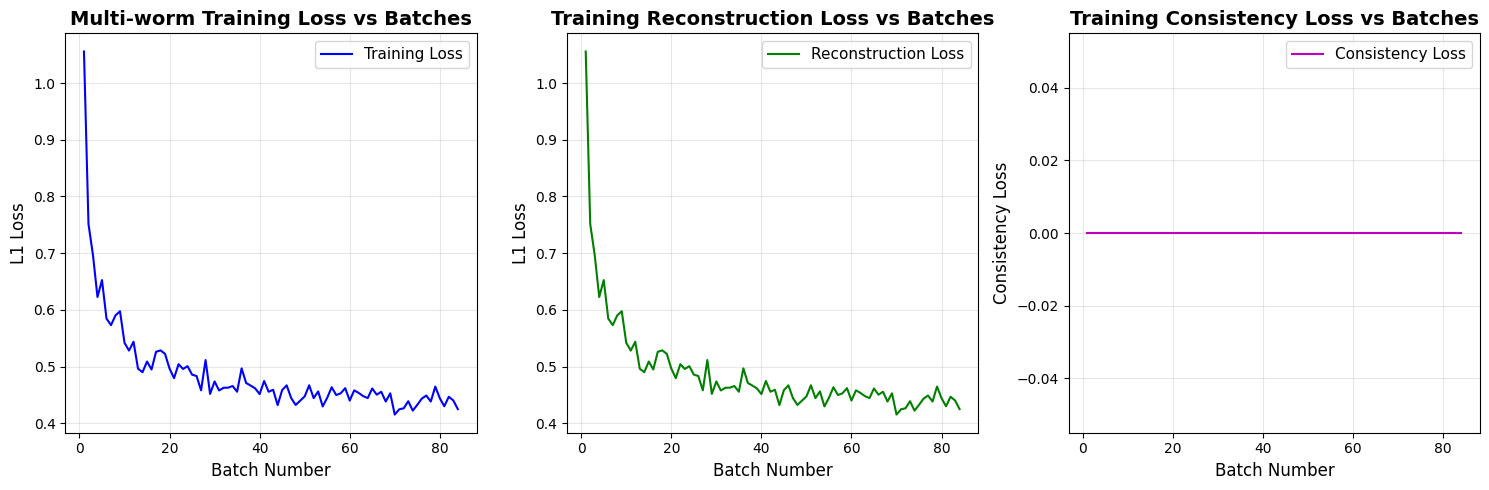

In [213]:
# Multi-worm training: Train on all but one (choose by index)
files = list_processed_worm_files()
if len(files) >= 2:
    held_idx = 0  # change as needed
    held_out = files[held_idx]
    train_files = files[:held_idx] + files[held_idx+1:]
    # DEBUG: Just train on one worm
    train_files = [random.choice(train_files)] # DEBUG
    print(f"\nTraining on {len(train_files)} worms, holding out: {held_out.name}")
    worm_loaders = build_worm_loaders(train_files, CONFIG_DYNAMICS, device)
    model = dynamics_model_factory(device)
    history_multiworm = train_multiworm(model, worm_loaders, CONFIG_DYNAMICS, device)

    # Plot training loss curves (similar to transcriptomics)
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(history_multiworm['batch_numbers'], history_multiworm['train_losses'], 'b-', label='Training Loss')
    plt.xlabel('Batch Number', fontsize=12)
    plt.ylabel('L1 Loss', fontsize=12)
    plt.title('Multi-worm Training Loss vs Batches', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.plot(history_multiworm['batch_numbers'], history_multiworm['train_recon_losses'], 'g-', label='Reconstruction Loss')
    plt.xlabel('Batch Number', fontsize=12)
    plt.ylabel('L1 Loss', fontsize=12)
    plt.title('Training Reconstruction Loss vs Batches', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    plt.plot(history_multiworm['batch_numbers'], history_multiworm['train_consist_losses'], 'm-', label='Consistency Loss')
    plt.xlabel('Batch Number', fontsize=12)
    plt.ylabel('Consistency Loss', fontsize=12)
    plt.title('Training Consistency Loss vs Batches', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Not enough processed worms found for held-out evaluation.")


Evaluating on held-out worm: atanas_kim_2023-2022-06-14-01_processed.npz

NeuralDynamicsDataset:
  N_neurons: 79
  Total timepoints: 1600
  seq_len: 128
  stride: 8
  n_windows: 185
Analyzing learned attention matrix from neural dynamics phase...


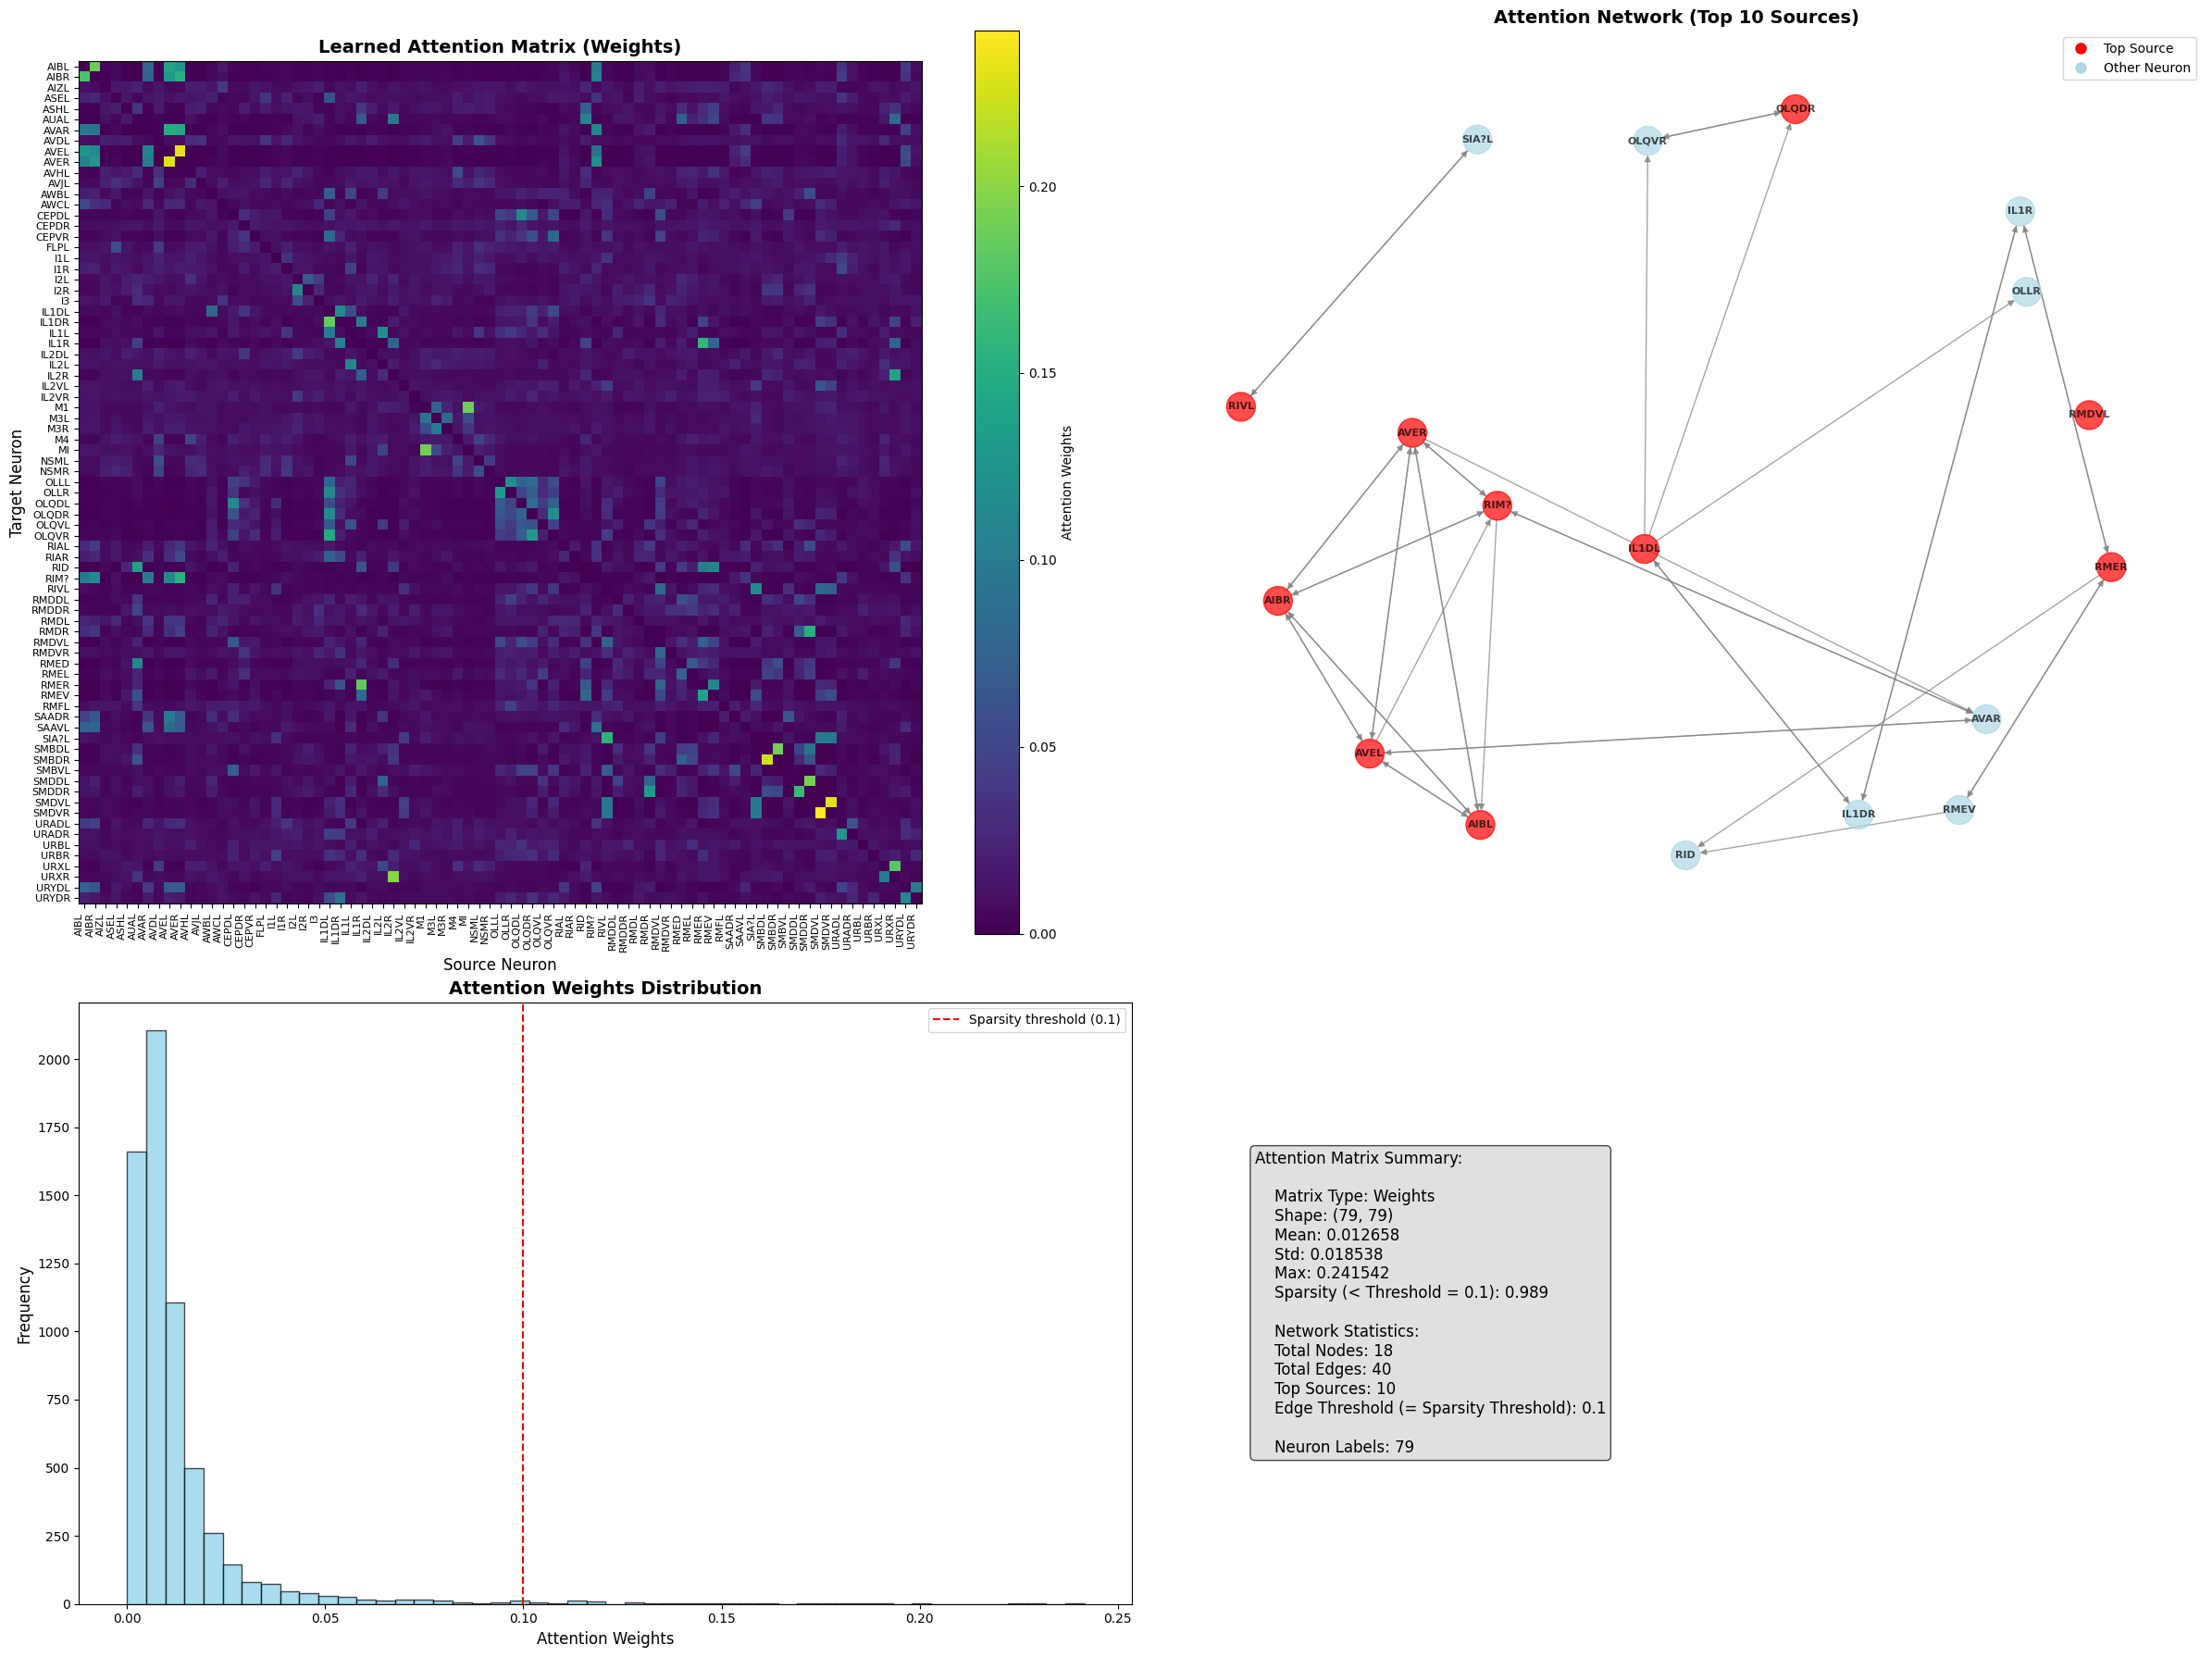


Attention matrix analysis complete for held-out worm: atanas_kim_2023-2022-06-14-01_processed.npz
  Attention matrix shape: (79, 79)
  Sparsity: 0.989
  Mean attention weight: 0.012658
  Std attention weight: 0.018538

Comparing learned attention matrix with ground-truth connectomes...

Comparing Ground-Truth Connectome to Learned Attention Matrix (NEURAL DYNAMICS VS WITVLIET CONNECTOME)

Comparing WITVLIET_COMBINED Connectome to Attention Matrix
Attention neurons: 113
Ground-truth neurons: 260
Overlapping neurons: 65
Overlap percentage: 25.0%
Full matrix shapes: Attention (79, 79), GT (260, 260)
Submatrix shapes: Attention (65, 65), GT (65, 65)
Correlation: r = 0.1912, p = 1.56e-35
Valid data points: 4160/4160


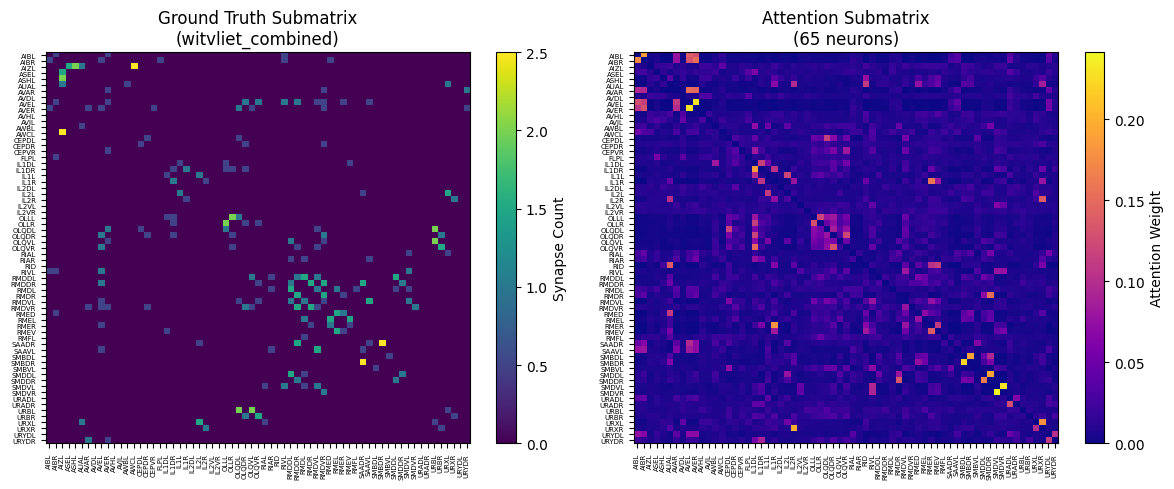


Matrix Statistics: NEURAL DYNAMICS VS WITVLIET CONNECTOME

Learned Attention Matrix:
  Shape: (79, 79)
  Mean: 0.012658
  Std: 0.018538
  Max: 0.241542
  Sparsity: 0.622

WITVLIET_COMBINED Comparison:
  Overlapping neurons: 65
  Correlation: r = 0.1912
  P-value: 1.56e-35
  Valid data points: 4160
  GT submatrix - Mean: 0.038935, Std: 0.206890, Max: 2.5
  GT submatrix - Sparsity: 0.955


In [214]:
# Evaluate on held-out worm
print(f"\nEvaluating on held-out worm: {held_out.name}")
held = load_worm_npz(held_out)
held_ds = make_dynamics_dataset_from_npz_dict(held, CONFIG_DYNAMICS['seq_len'], CONFIG_DYNAMICS['stride'], device)

# Analyze attention matrix
print("Analyzing learned attention matrix from neural dynamics phase...")
attn_eval_heldout = analyze_attention_matrix(
    model, 
    held_ds, 
    held['neuron_labels'],  # Use held-out worm's neuron labels
    device,
    use_attention_scores=CONFIG_DYNAMICS.get('use_attention_scores', False)
)

print(f"\nAttention matrix analysis complete for held-out worm: {held_out.name}")
print(f"  Attention matrix shape: {attn_eval_heldout['attention_matrix'].shape}")
print(f"  Sparsity: {attn_eval_heldout['sparsity']:.3f}")
print(f"  Mean attention weight: {attn_eval_heldout['mean']:.6f}")
print(f"  Std attention weight: {attn_eval_heldout['std']:.6f}")

# Compare with ground-truth connectomes
print("\n" + "="*80)
print("Comparing learned attention matrix with ground-truth connectomes...")
print("="*80)

# Compare with Witvliet structural connectome
comparison_results_witvliet = compare_attention_with_ground_truth(
    attention_matrix=attn_eval_heldout['attention_matrix'],
    attention_neuron_labels=held['neuron_labels'],  # Use held-out worm's labels
    ground_truth_matrices={
        'witvliet_combined': gt_adj_combined
    },
    ground_truth_neuron_labels={
        'witvliet_combined': neurons_7_8_all
    },
    phase_name="Neural Dynamics vs Witvliet Connectome",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)


#### Leave-one-out cross-validation 

We train a model on all worms except one, and evaluate on the held-out worm. We repeat this process for each worm, and report the average performance.

In [215]:
# # 6) Leave-one-out cross-validation runner
# def run_leave_one_out_cv(model_factory, config, device):
#     files = list_processed_worm_files()
#     results = {}
#     for i in range(len(files)):
#         held_out = files[i]
#         train_files = files[:i] + files[i+1:]
#         # DEBUG: Just train on one worm
#         train_files = [random.choice(train_files)] # DEBUG
#         print(f"\n=== Fold {i+1}/{len(files)}: held-out {held_out.name} ===")
#         worm_loaders = build_worm_loaders(train_files, config, device)
#         model = model_factory(device)

#         # Train across all training worms
#         hist = train_multiworm(model, worm_loaders, config, device)

#         # Evaluate on held-out
#         held = load_worm_npz(held_out)
#         held_ds = make_dynamics_dataset_from_npz_dict(held, config['seq_len'], config['stride'], device)
#         held_loader = DataLoader(held_ds, batch_size=config['batch_size'], shuffle=False)

#         # Reuse your updated analysis which handles dict outputs
#         attn_eval = analyze_attention_matrix(
#             model, 
#             held_ds,  # dataset, not loader
#             held['neuron_labels'],  
#             device,
#             use_attention_scores=config.get('use_attention_scores', False)
#         )
#         results[held_out.name] = {
#             'history': hist,
#             'attn_eval': attn_eval,
#             'labels': held['neuron_labels'],
#             'meta': held['metadata']
#         }
#     return results

# # Full leave-one-out CV (can be long)
# loocv_results = run_leave_one_out_cv(dynamics_model_factory, CONFIG_DYNAMICS, device)

## Functional Connectome Data (Randi et al. 2023)

We now load functional connectome data from Randi et al. (2023) which provides neural signal propagation measurements. This data represents functional connectivity based on calcium imaging experiments where neurons were stimulated and responses were recorded across the network.

**Data Structure:**
- **Sheet 1**: "Figure2a, df_over_f" - Normalized change in fluorescence (df/f) values
- **Sheet 2**: "Figure2a, alpha=(1 - q_val)" - Statistical significance values
- **Format**: 168 neurons × 168 neurons matrix
- **Values**: Can be positive (excitatory), negative (inhibitory), or NaN (not measured)

**Reference:**
> Randi, F., Sharma, A.K., Dvali, S. et al. Neural signal propagation atlas of Caenorhabditis elegans. Nature 623, 406–414 (2023). https://doi.org/10.1038/s41586-023-06683-4


In [216]:
# Load Randi 2023 functional connectome data
print("Loading Randi 2023 functional connectome data...")

# Load both sheets
functional_df_over_f = pd.read_excel(
    'data/connectomics/CElegansFunctionalConnectivity.xlsx',
    sheet_name='Figure2a, df_over_f'
)
functional_alpha = pd.read_excel(
    'data/connectomics/CElegansFunctionalConnectivity.xlsx',
    sheet_name='Figure2a, alpha=(1 - q_val)'
)

# Extract neuron names from first column
neuron_names_functional = functional_df_over_f.iloc[:, 0].tolist()  # Row names
column_names = functional_df_over_f.columns[1:].tolist()  # Column names (skip first column)

print(f"Functional connectome shape: {functional_df_over_f.shape}")
print(f"Number of neurons: {len(neuron_names_functional)}")
print(f"Sample neurons: {neuron_names_functional[:10]}")

def matrix_to_edgelist(matrix_df, neuron_names, type_value, alpha_df=None, alpha_threshold=0.05):
    """
    Convert neuron x neuron matrix to edge-list format as ['pre', 'post', 'type', 'functional'].
    The 'type' column is filled with type_value (e.g. 'df_over_f', 'alpha_1minus_q'), and 
    the 'functional' column contains the value from the matrix (after thresholding/cleaning).
    """
    edges = []

    matrix_values = matrix_df.iloc[:, 1:].values
    if alpha_df is not None:
        alpha_values = alpha_df.iloc[:, 1:].values
    else:
        alpha_values = None

    for i, pre_neuron in enumerate(neuron_names):
        for j, post_neuron in enumerate(neuron_names):
            # Zero out self-connections for consistency with typical convention
            if i == j:
                functional_value = 0.0
            else:
                functional_value = matrix_values[i, j]
                if pd.isna(functional_value):
                    functional_value = 0.0

                # If using alpha filtering, filter by significance
                if alpha_values is not None:
                    alpha_val = alpha_values[i, j]
                    # If not significant or undefined, treat as absent connection
                    if pd.isna(alpha_val) or alpha_val < alpha_threshold:
                        functional_value = 0.0

            edges.append({
                'pre': pre_neuron,
                'post': post_neuron,
                'type': type_value,
                'functional': functional_value
            })
    return pd.DataFrame(edges)

# Create edge-list for df_over_f (raw, no filter)
functional_edgelist_raw = matrix_to_edgelist(
    functional_df_over_f,
    neuron_names_functional,
    type_value='df_over_f',
    alpha_df=None
)

# Create edge-list for df_over_f with alpha significance filtering
functional_edgelist_filtered = matrix_to_edgelist(
    functional_df_over_f,
    neuron_names_functional,
    type_value='df_over_f',
    alpha_df=functional_alpha,
    alpha_threshold=0.05
)

# Create edge-list for alpha (full alpha matrix, for possible significance visualization/stats)
functional_edgelist_alpha = matrix_to_edgelist(
    functional_alpha,
    neuron_names_functional,
    type_value='alpha_1minus_q',
    alpha_df=None
)

print(f"\nRaw functional edge-list shape: {functional_edgelist_raw.shape}")
print(f"Filtered functional edge-list shape: {functional_edgelist_filtered.shape}")
print(f"Alpha edge-list shape: {functional_edgelist_alpha.shape}")
print(f"Non-zero connections (raw): {(functional_edgelist_raw['functional'] != 0).sum()}")
print(f"Non-zero connections (filtered): {(functional_edgelist_filtered['functional'] != 0).sum()}")
print(f"Non-zero alpha entries: {(functional_edgelist_alpha['functional'] != 0).sum()}")

print("\nSample edges (raw, df_over_f):")
print(functional_edgelist_raw[functional_edgelist_raw['functional'] != 0].head())

print("\nSample edges (alpha):")
print(functional_edgelist_alpha[functional_edgelist_alpha['functional'] != 0].head())



Loading Randi 2023 functional connectome data...
Functional connectome shape: (168, 169)
Number of neurons: 168
Sample neurons: ['ADEL', 'ADER', 'ADFL', 'ADLL', 'ADLR', 'AFDL', 'AFDR', 'AQR', 'ASEL', 'ASER']

Raw functional edge-list shape: (28224, 4)
Filtered functional edge-list shape: (28224, 4)
Alpha edge-list shape: (28224, 4)
Non-zero connections (raw): 22353
Non-zero connections (filtered): 11006
Non-zero alpha entries: 12033

Sample edges (raw, df_over_f):
    pre  post       type  functional
1  ADEL  ADER  df_over_f    0.490587
2  ADEL  ADFL  df_over_f    0.117402
3  ADEL  ADLL  df_over_f   -0.011007
6  ADEL  AFDR  df_over_f    0.016940
7  ADEL   AQR  df_over_f    0.102774

Sample edges (alpha):
     pre  post            type  functional
1   ADEL  ADER  alpha_1minus_q    0.947234
2   ADEL  ADFL  alpha_1minus_q    0.098413
7   ADEL   AQR  alpha_1minus_q    0.994309
10  ADEL  ASGL  alpha_1minus_q    0.759721
16  ADEL  ASJL  alpha_1minus_q    0.103646


In [217]:
# Create adjacency matrices for functional connectome
print("\nCreating functional connectome adjacency matrices...")

# Raw (unfiltered)
functional_adj_raw = create_adjacency_matrix(
    functional_edgelist_raw,
    neuron_names_functional,
    weight_col='functional',   # Corrected: use 'functional' column in edge-list
    synapse_type='df_over_f'   # Only take rows where type == 'df_over_f'
)

# Significance-filtered
functional_adj_filtered = create_adjacency_matrix(
    functional_edgelist_filtered,
    neuron_names_functional,
    weight_col='functional',   # Corrected: use 'functional' column
    synapse_type='df_over_f'
)

print(f"Functional adjacency matrix (raw) shape: {functional_adj_raw.shape}")
print(f"Functional adjacency matrix (filtered) shape: {functional_adj_filtered.shape}")
print(f"Raw matrix - mean: {functional_adj_raw.mean():.6f}, std: {functional_adj_raw.std():.6f}")
print(f"Filtered matrix - mean: {functional_adj_filtered.mean():.6f}, std: {functional_adj_filtered.std():.6f}")



Creating functional connectome adjacency matrices...
Functional adjacency matrix (raw) shape: (168, 168)
Functional adjacency matrix (filtered) shape: (168, 168)
Raw matrix - mean: 0.028095, std: 0.083492
Filtered matrix - mean: 0.020623, std: 0.076213



Comparing Ground-Truth Connectome to Learned Attention Matrix (NEURAL DYNAMICS VS FUNCTIONAL CONNECTOME)

Comparing FUNCTIONAL_RAW Connectome to Attention Matrix
Attention neurons: 113
Ground-truth neurons: 236
Overlapping neurons: 74
Overlap percentage: 31.4%
Full matrix shapes: Attention (79, 79), GT (168, 168)
Submatrix shapes: Attention (74, 74), GT (74, 74)
Correlation: r = 0.1322, p = 1.72e-22
Valid data points: 5402/5402


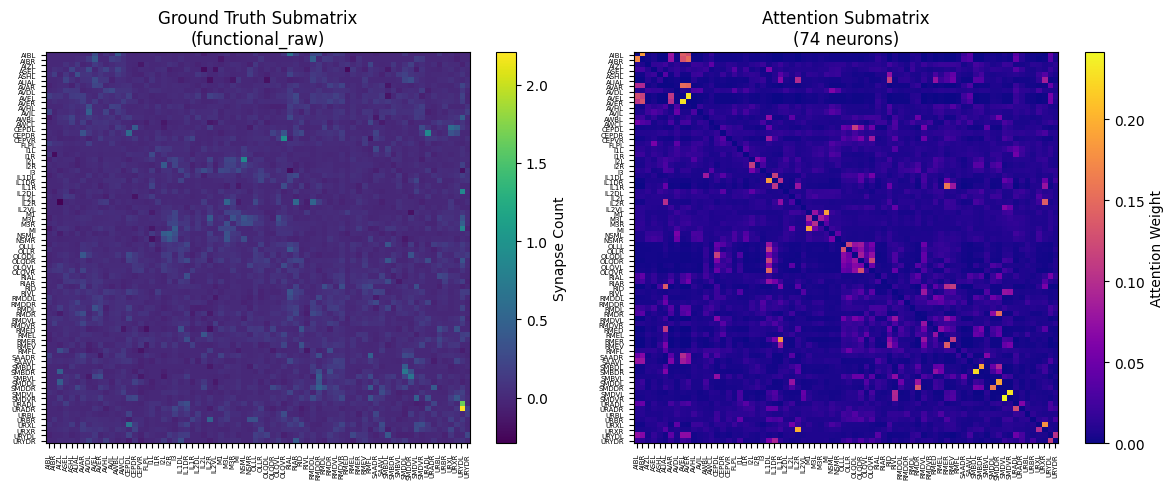


Comparing FUNCTIONAL_FILTERED Connectome to Attention Matrix
Attention neurons: 113
Ground-truth neurons: 236
Overlapping neurons: 74
Overlap percentage: 31.4%
Full matrix shapes: Attention (79, 79), GT (168, 168)
Submatrix shapes: Attention (74, 74), GT (74, 74)
Correlation: r = 0.1323, p = 1.65e-22
Valid data points: 5402/5402


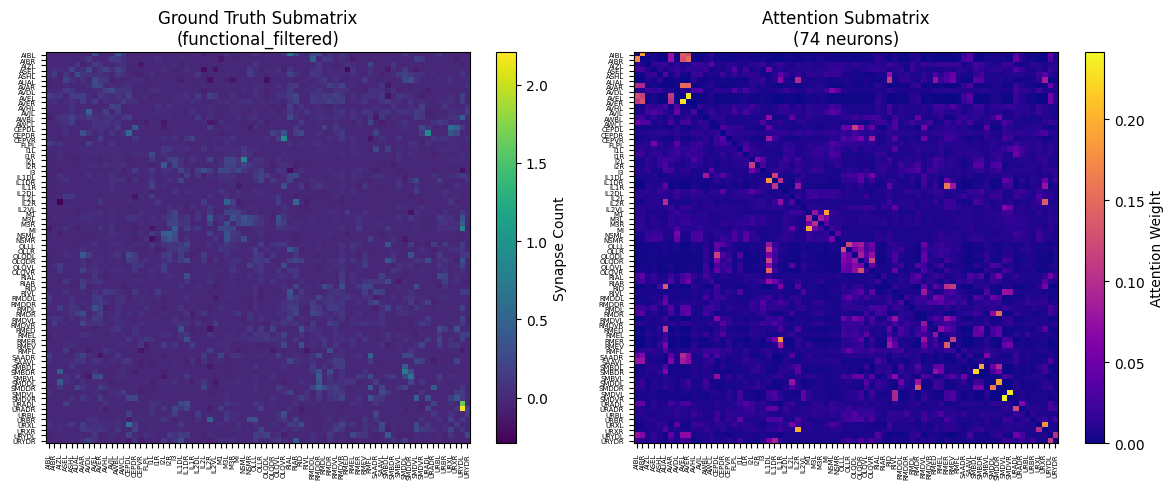


Matrix Statistics: NEURAL DYNAMICS VS FUNCTIONAL CONNECTOME

Learned Attention Matrix:
  Shape: (79, 79)
  Mean: 0.012658
  Std: 0.018538
  Max: 0.241542
  Sparsity: 0.622

FUNCTIONAL_RAW Comparison:
  Overlapping neurons: 74
  Correlation: r = 0.1322
  P-value: 1.72e-22
  Valid data points: 5402
  GT submatrix - Mean: 0.036982, Std: 0.087660, Max: 2.2
  GT submatrix - Sparsity: 0.158

FUNCTIONAL_FILTERED Comparison:
  Overlapping neurons: 74
  Correlation: r = 0.1323
  P-value: 1.65e-22
  Valid data points: 5402
  GT submatrix - Mean: 0.029106, Std: 0.084696, Max: 2.2
  GT submatrix - Sparsity: 0.545


In [218]:
# Compare with functional connectome
comparison_results_functional = compare_attention_with_ground_truth(
    attention_matrix=attn_eval_heldout['attention_matrix'],
    attention_neuron_labels=held['neuron_labels'],  # Use held-out worm's labels
    ground_truth_matrices={
        'functional_raw': functional_adj_raw,
        'functional_filtered': functional_adj_filtered
    },
    ground_truth_neuron_labels={
        'functional_raw': neuron_names_functional,
        'functional_filtered': neuron_names_functional
    },
    phase_name="Neural Dynamics vs Functional Connectome",
    label_to_class_mapping=label_to_class,
    exclude_bwm=True
)